# EDA — IEEE-CIS Fraud Detection (Consolidated)

Consolidates EDA.ipynb and EDA_2.ipynb into a single reference notebook, plus the
correlation-based column reduction that feeds `src/model/preprocess.py`.

1. Data quality & missingness
2. Target variable deep-dive (categorical breakdowns)
3. TransactionDT — time analysis
4. Numerical feature distributions (TransactionAmt, C, D, numeric id_ columns)
5. Correlation heatmap & redundancy (non-V columns)
6. V-column NaN-pattern clustering (grouping for PCA, not raw value plots — 339 columns is too many to plot individually)
7. Summary: final drop-column / grouping decisions


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

from utils import frequency_encode, plot_columns, ploting_cnt_amt 

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
project_root = Path.cwd().parents[1]
df_train_transaction = pd.read_csv(project_root / 'data' / 'raw' / 'train_transaction.csv')
df_train_identity    = pd.read_csv(project_root / 'data' / 'raw' / 'train_identity.csv')
df = df_train_transaction.merge(df_train_identity, on='TransactionID', how='left')

print(f'Transaction table: {df_train_transaction.shape}')
print(f'Identity table:    {df_train_identity.shape}')
print(f'Merged:            {df.shape}')

Transaction table: (590540, 394)
Identity table:    (144233, 41)
Merged:            (590540, 434)


In [3]:
df_test_transaction = pd.read_csv(project_root / 'data' / 'raw' / 'test_transaction.csv')
df_test_identity    = pd.read_csv(project_root / 'data' / 'raw' / 'test_identity.csv')
df_test = df_test_transaction.merge(df_test_identity, on='TransactionID', how='left')

print(f'Transaction table: {df_test_transaction.shape}')
print(f'Identity table:    {df_test_identity.shape}')
print(f'Merged:            {df_test.shape}')

Transaction table: (506691, 393)
Identity table:    (141907, 41)
Merged:            (506691, 433)


## Fraud distribution

Only 3.5% of training transactions are fraud — every metric downstream (AUPRC over AUROC,
`scale_pos_weight`, cost-sensitive scoring) exists because of this imbalance.

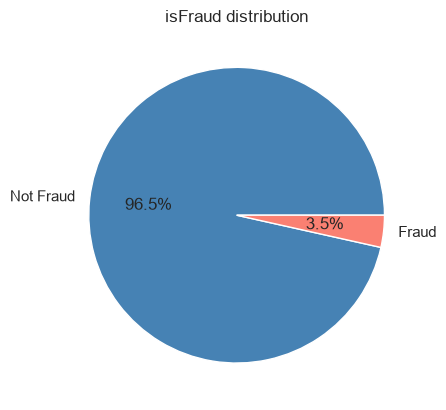

In [4]:
df_train_transaction['isFraud'].value_counts().plot(
    kind='pie', labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%',
    colors=['steelblue', 'salmon'], ylabel='')
plt.title('isFraud distribution')
plt.show()

## 1. Data Quality & Missingness

Key questions:
- Which columns have too many NaNs to be useful?
- Do V-column NaN patterns reveal hidden column groupings (Vesta transaction pathways)?
- How many transactions have identity records?

In [5]:
nan_rate = df_train_transaction.isna().mean().sort_values(ascending=False)
print('Top 20 columns by NaN rate:')
print(nan_rate.head(20).to_string())

# No transaction or identity column exceeds 98% NaN in this dataset.
high_nan_98 = nan_rate[nan_rate > 0.98].index.tolist()
high_nan_90 = nan_rate[nan_rate > 0.90].index.tolist()
print(f'\nColumns >98% NaN: {high_nan_98}')
print(f'Columns >90% NaN: {high_nan_90}')

Top 20 columns by NaN rate:
dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V139     0.861237
V162     0.861237
V161     0.861237
V154     0.861237
V138     0.861237
V158     0.861237
V157     0.861237
V163     0.861237
V156     0.861237
V155     0.861237
V149     0.861237

Columns >98% NaN: []
Columns >90% NaN: ['dist2', 'D7']


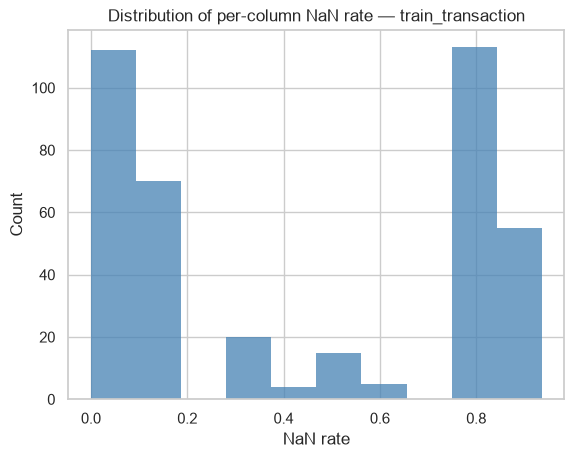

In [5]:
sns.histplot(nan_rate, color='steelblue', edgecolor='none')
plt.title('Distribution of per-column NaN rate — train_transaction')
plt.xlabel('NaN rate')
plt.show()

C:\Users\zheng\AppData\Local\Temp\ipykernel_30984\3754440750.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


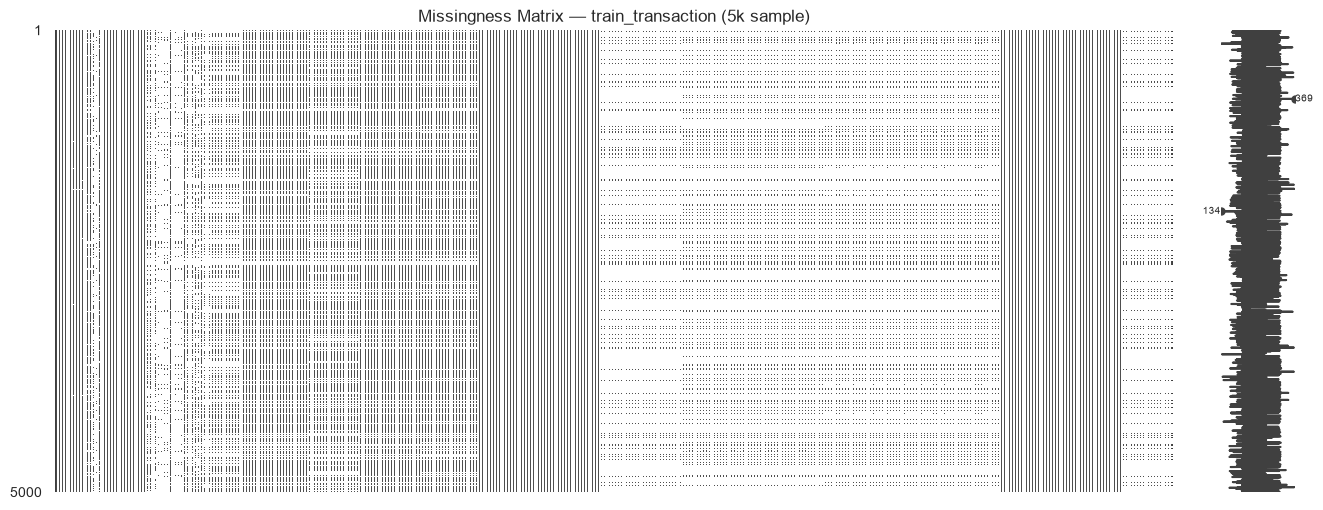

In [6]:
sample = df_train_transaction.sample(5000, random_state=42)
msno.matrix(sample, figsize=(16, 6), fontsize=8)
plt.title('Missingness Matrix — train_transaction (5k sample)')
plt.tight_layout()
plt.show()

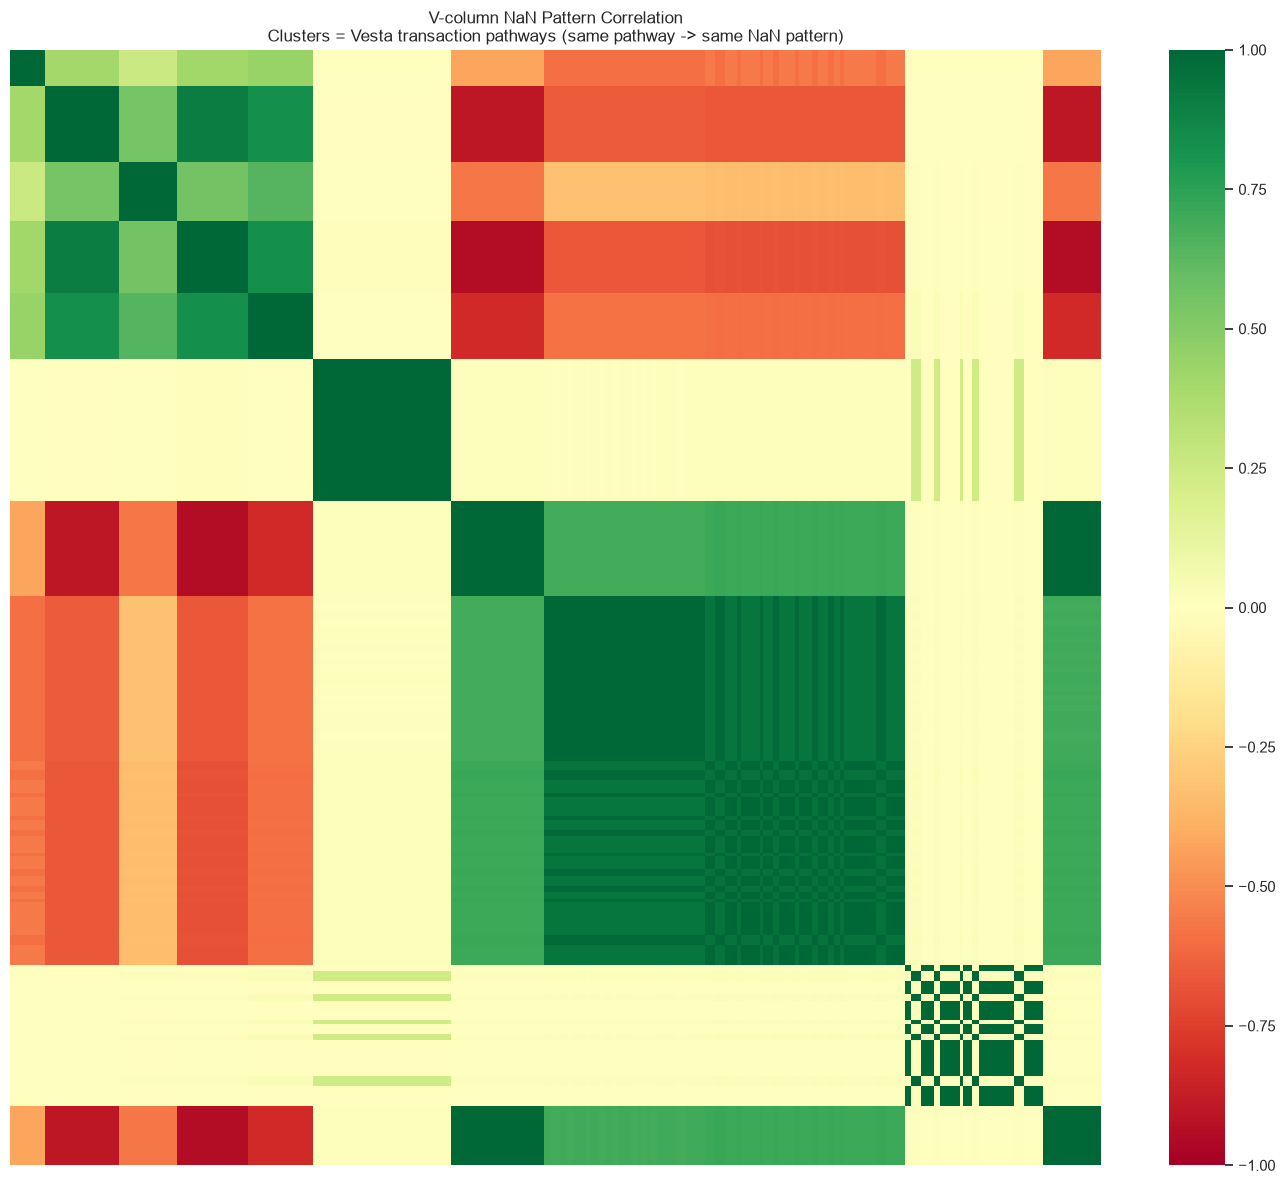

In [7]:
# V-column NaN pattern correlation — clusters reveal Vesta's hidden transaction pathways.
# Values are NEVER plotted individually (339 columns); only their missingness pattern.
v_cols = [c for c in df_train_transaction.columns if c.startswith('V')]
v_nan_corr = df_train_transaction[v_cols].isna().astype(int).corr()

plt.figure(figsize=(14, 12))
sns.heatmap(v_nan_corr, cmap='RdYlGn', center=0,
            xticklabels=False, yticklabels=False, vmin=-1, vmax=1)
plt.title('V-column NaN Pattern Correlation\n'
          'Clusters = Vesta transaction pathways (same pathway -> same NaN pattern)')
plt.tight_layout()
plt.show()

TransactionID
No Identity Record     446307
Has Identity Record    144233
Name: count, dtype: int64


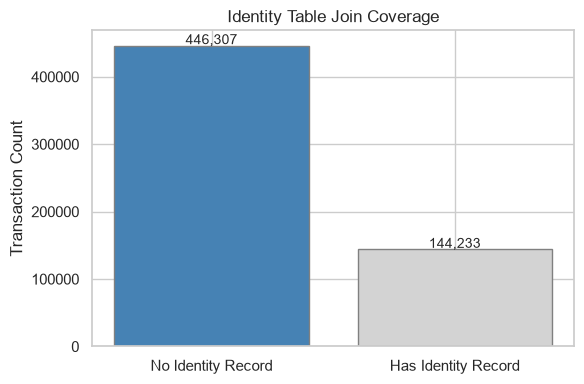

In [8]:
has_identity = df_train_transaction['TransactionID'].isin(df_train_identity['TransactionID'])
counts = has_identity.value_counts().rename({True: 'Has Identity Record', False: 'No Identity Record'})
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=['steelblue', 'lightgray'], edgecolor='gray')
ax.set_ylabel('Transaction Count')
ax.set_title('Identity Table Join Coverage')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Target Variable Deep-Dive

The overall 3.5% fraud rate masks large variation across product types, card categories, and devices.
These breakdowns directly inform business rule design (e.g. higher scrutiny for product C = cash advance).

## 2.1 Categorical variables

### ProductCD

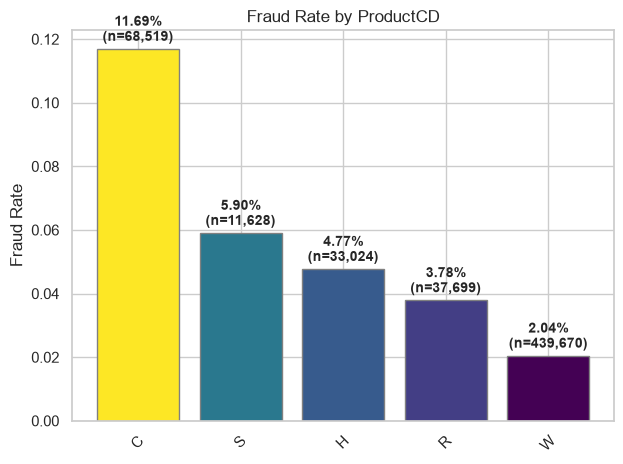

In [8]:
fraud_rate = df_train_transaction.groupby('ProductCD', dropna=False)['isFraud'].mean().sort_values(ascending=False)
count = df_train_transaction.groupby('ProductCD', dropna=False)['isFraud'].count().reindex(fraud_rate.index)

norm = plt.Normalize(fraud_rate.values.min(), fraud_rate.values.max())
colors = plt.colormaps['viridis'](norm(fraud_rate.values))
bars = plt.bar(fraud_rate.index, height=fraud_rate.values, color=colors, edgecolor='gray')
labels = [f'{rate:.2%}\n(n={cnt:,})' for rate, cnt in zip(fraud_rate.values, count.values)]
plt.gca().bar_label(bars, labels=labels, padding=3, fontsize=10, fontweight='bold')
plt.title('Fraud Rate by ProductCD')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**: ProductCD `C` (cash advance) has the highest fraud rate by a wide margin.

### card1–card6

card1, card2, card3, card5 have too many unique values for direct plotting — frequency-encode them to preserve "rare vs frequent" signal without exploding dimensionality (vs. one-hot or bucketing rare values into a single "Other").

In [29]:
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
for c in card_cols:
    print(f'{c}: {df[c].nunique()} unique values')

card1: 13553 unique values
card2: 500 unique values
card3: 114 unique values
card4: 4 unique values
card5: 119 unique values
card6: 4 unique values


c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].map(df[col].value_counts())
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].map(df[col].value_counts())
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

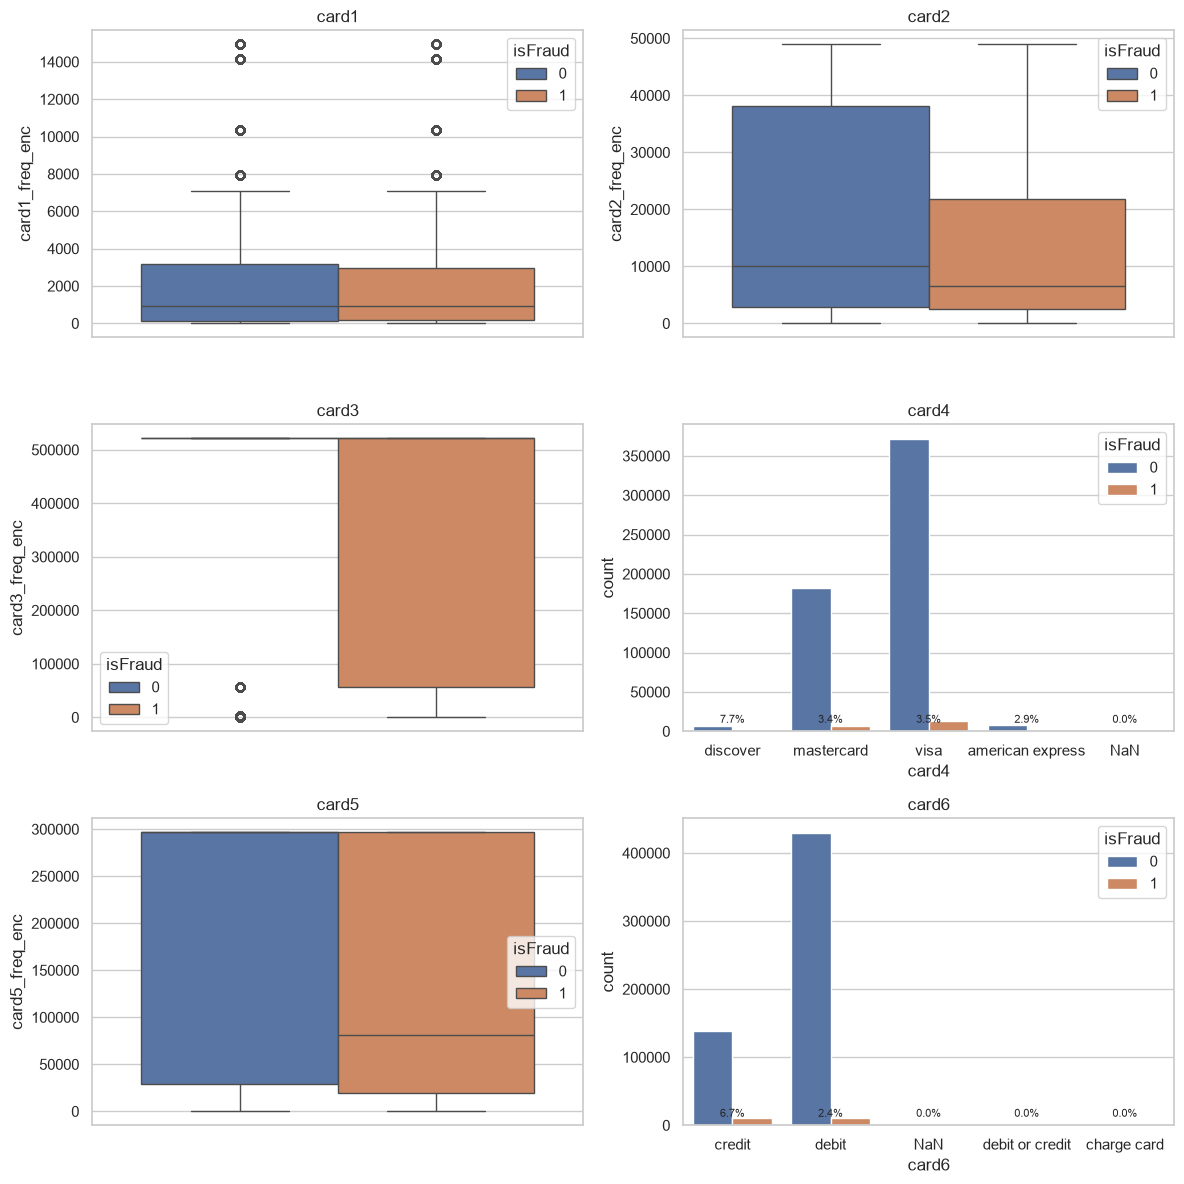

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, curr_col in zip(axes.flat, card_cols):
    if df[curr_col].nunique() > 20:
        frequency_encode(df, curr_col, f'{curr_col}_freq_enc')
        sns.boxplot(data=df, y=f'{curr_col}_freq_enc', hue='isFraud', ax=ax)
    else:
        plot_col = df[curr_col].fillna('NaN')
        sns.countplot(x=plot_col, hue=df['isFraud'], ax=ax)
        rates = df.groupby(curr_col, dropna=False)['isFraud'].mean()
        categories = [t.get_text() for t in ax.get_xticklabels()]
        for i, cat in enumerate(categories):
            rate = rates[cat] if cat in rates.index else 0
            ymax = ax.get_ylim()[1]
            ax.text(i, ymax * 0.02, f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(curr_col)

plt.tight_layout()
plt.show()

**Observations**: card3 fraud is concentrated in the less-frequent values (low freq-encoded value).
card4 = discover has the highest fraud rate among networks; card6 = credit has a higher fraud rate than debit.

### addr1, addr2

In [31]:
addr_cols = ['addr1', 'addr2']
for c in addr_cols:
    print(f'{c}: {df[c].nunique()} unique values, NaN rate {df[c].isna().mean():.1%}')

addr1: 332 unique values, NaN rate 11.1%
addr2: 74 unique values, NaN rate 11.1%


Likewise, there is high number of unique address values, which is to be expected. Frequency encoding can be used again

c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].map(df[col].value_counts())
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].map(df[col].value_counts())


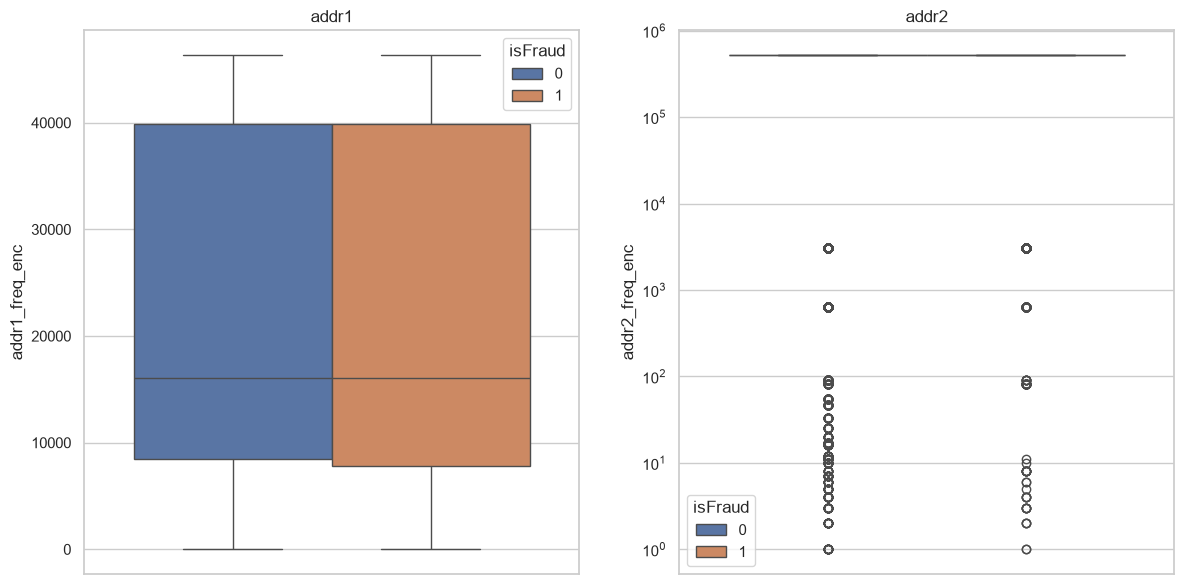

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, curr_col in zip(axes.flat, addr_cols):
    frequency_encode(df, curr_col, f'{curr_col}_freq_enc')
    sns.boxplot(data=df, y=f'{curr_col}_freq_enc', hue='isFraud', ax=ax)
    ax.set_title(curr_col)
plt.tight_layout()
plt.yscale('log')
plt.show()

No strong, immediately obvious relationship between address frequency and fraud — addr1/addr2 are kept as frequency-encoded features but are not standout signals on their own.

### P_emaildomain, R_emaildomain

In [33]:
df["P_emaildomain"].unique()

<ArrowStringArray>
[               nan,        'gmail.com',      'outlook.com',
        'yahoo.com',         'mail.com',    'anonymous.com',
      'hotmail.com',      'verizon.net',          'aol.com',
           'me.com',      'comcast.net',    'optonline.net',
          'cox.net',      'charter.net',   'rocketmail.com',
   'prodigy.net.mx',   'embarqmail.com',       'icloud.com',
      'live.com.mx',            'gmail',         'live.com',
          'att.net',         'juno.com',        'ymail.com',
    'sbcglobal.net',    'bellsouth.net',          'msn.com',
            'q.com',     'yahoo.com.mx',  'centurylink.net',
 'servicios-ta.com',    'earthlink.net',       'hotmail.es',
       'cfl.rr.com',   'roadrunner.com',      'netzero.net',
           'gmx.de',   'suddenlink.net',  'frontiernet.net',
   'windstream.net',     'frontier.com',       'outlook.es',
          'mac.com',      'netzero.com',          'aim.com',
           'web.de',          'twc.com',     'cableone.net',
     

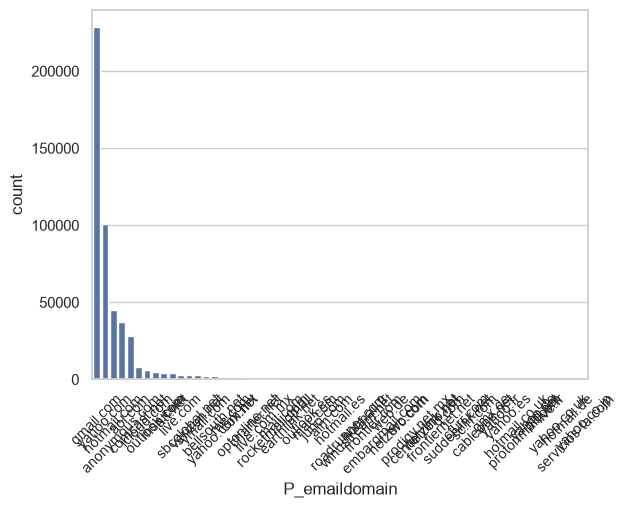

In [34]:
sns.countplot(data=df, x="P_emaildomain", order=df["P_emaildomain"].value_counts().index)
plt.tick_params(axis='x', rotation=45, labelsize=10)
plt.show()

In [35]:
df.loc[df['P_emaildomain'].isin(['gmail.com', 'gmail']),'P_emaildomain'] = 'Google'

df.loc[df['P_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                         'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                         'yahoo.es']), 'P_emaildomain'] = 'Yahoo Mail'
df.loc[df['P_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx',
                                         'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                         'outlook.es', 'live.com', 'live.fr',
                                         'hotmail.fr']), 'P_emaildomain'] = 'Microsoft'
df.loc[df['P_emaildomain'].isin(df["P_emaildomain"].value_counts()[df["P_emaildomain"].value_counts() <= 500].index), 'P_emaildomain'] = "Others"

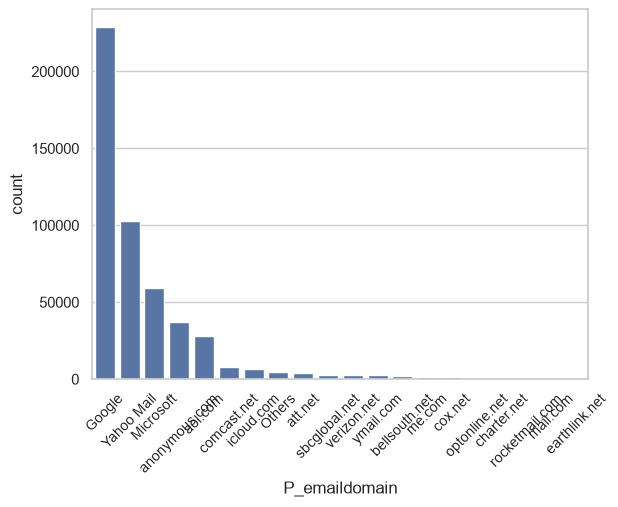

In [36]:
sns.countplot(data=df, x="P_emaildomain", order=df["P_emaildomain"].value_counts().index)
plt.tick_params(axis='x', rotation=45, labelsize=10)
plt.show()

c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.set_xticklabels(g.get_xticklabels(),rotation=45)
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.set_xticklabels(g.get_xticklabels(),rotation=45)
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g1.set_xticklabels(g.get_xticklabels(),rotation=45)


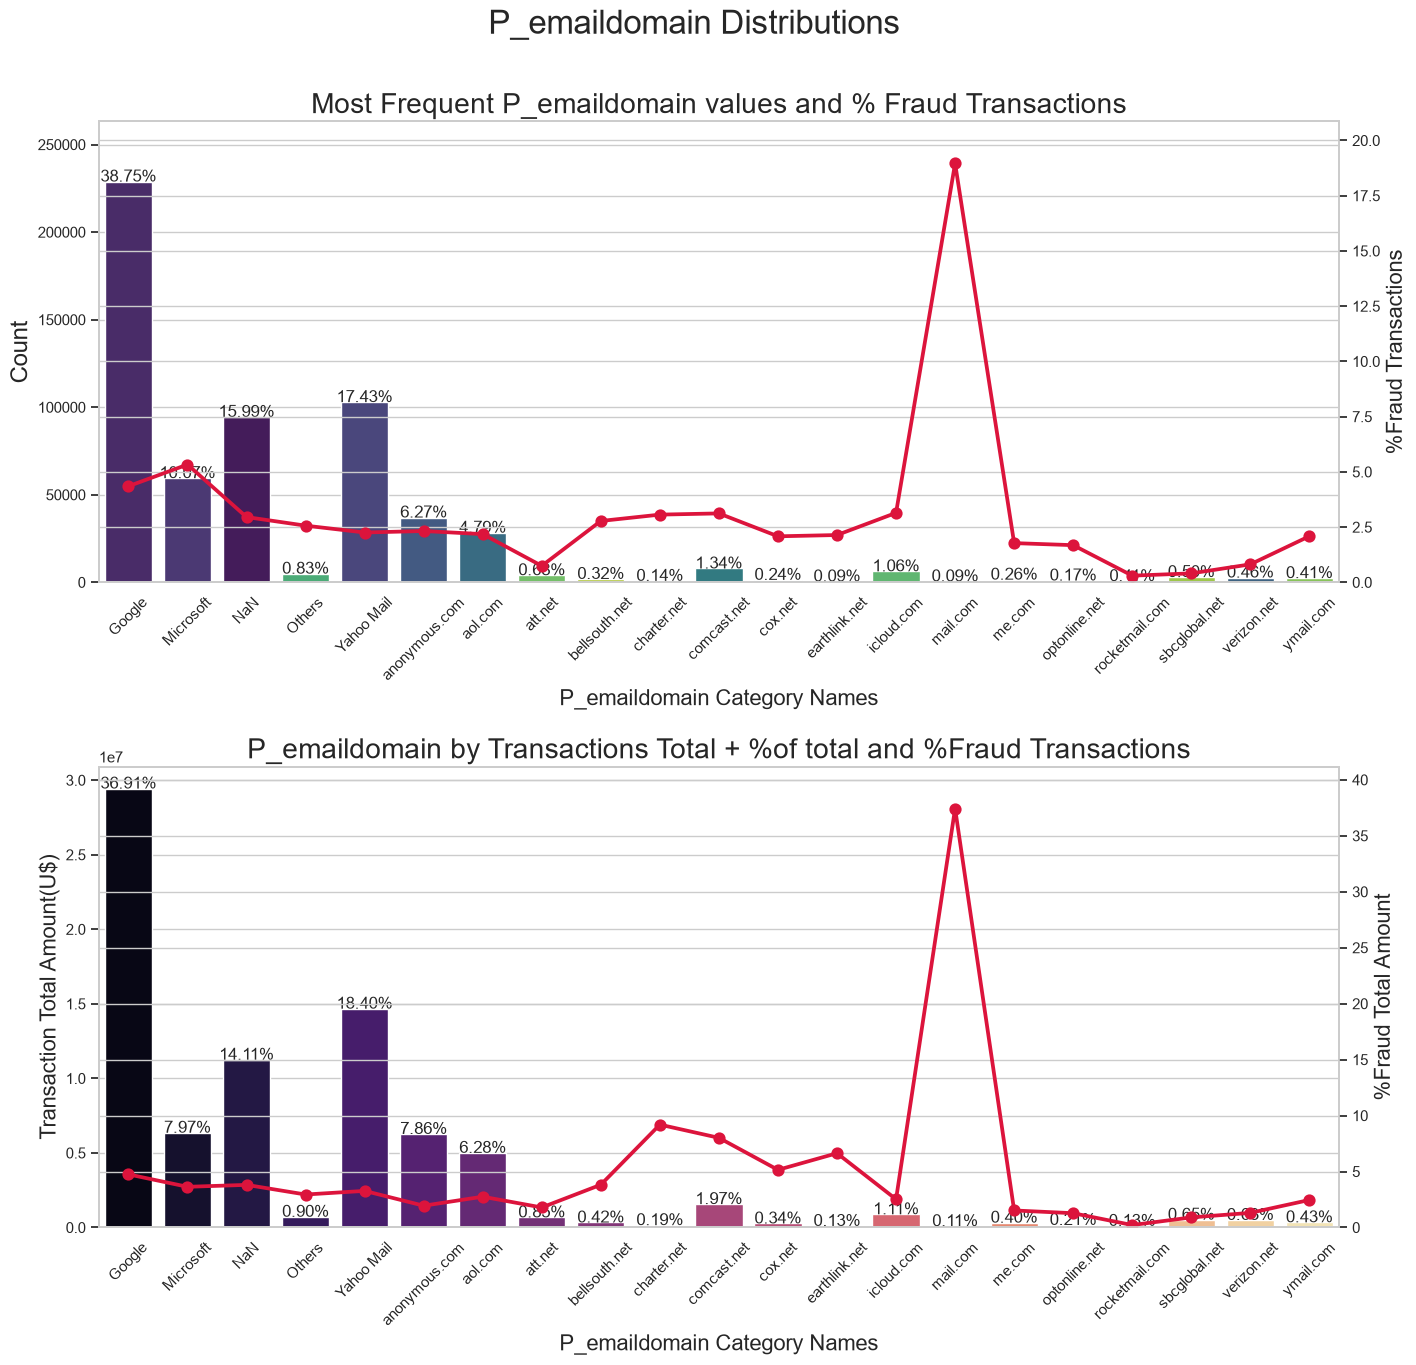

In [37]:
ploting_cnt_amt(df, 'P_emaildomain')

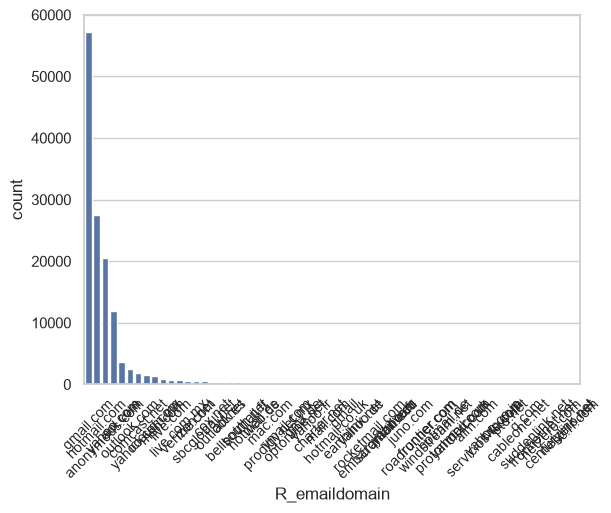

In [30]:
sns.countplot(data=df, x="R_emaildomain", order=df["R_emaildomain"].value_counts().index)
plt.tick_params(axis='x', rotation=45, labelsize=10)
plt.show()

In [38]:
df.loc[df['R_emaildomain'].isin(['gmail.com', 'gmail']),'R_emaildomain'] = 'Google'

df.loc[df['R_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                             'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                             'yahoo.es']), 'R_emaildomain'] = 'Yahoo Mail'
df.loc[df['R_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx', 
                                             'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                             'outlook.es', 'live.com', 'live.fr',
                                             'hotmail.fr']), 'R_emaildomain'] = 'Microsoft'
df.loc[df.R_emaildomain.isin(df.R_emaildomain\
                                         .value_counts()[df.R_emaildomain.value_counts() <= 300 ]\
                                         .index), 'R_emaildomain'] = "Others"

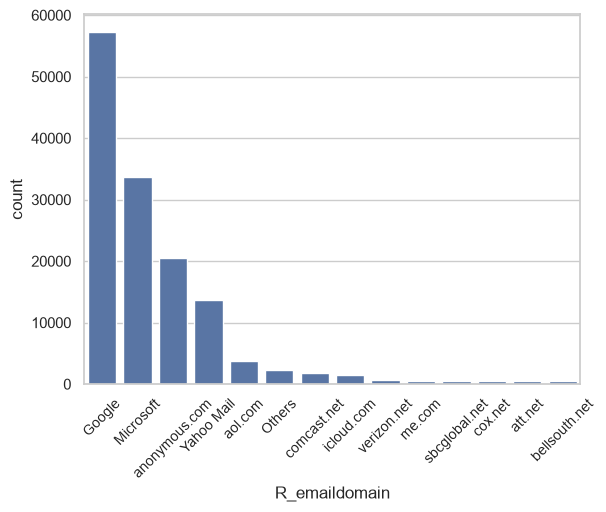

In [39]:
sns.countplot(data=df, x="R_emaildomain", order=df["R_emaildomain"].value_counts().index)
plt.tick_params(axis='x', rotation=45, labelsize=10)
plt.show()

c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.set_xticklabels(g.get_xticklabels(),rotation=45)
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.set_xticklabels(g.get_xticklabels(),rotation=45)
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g1.set_xticklabels(g.get_xticklabels(),rotation=45)


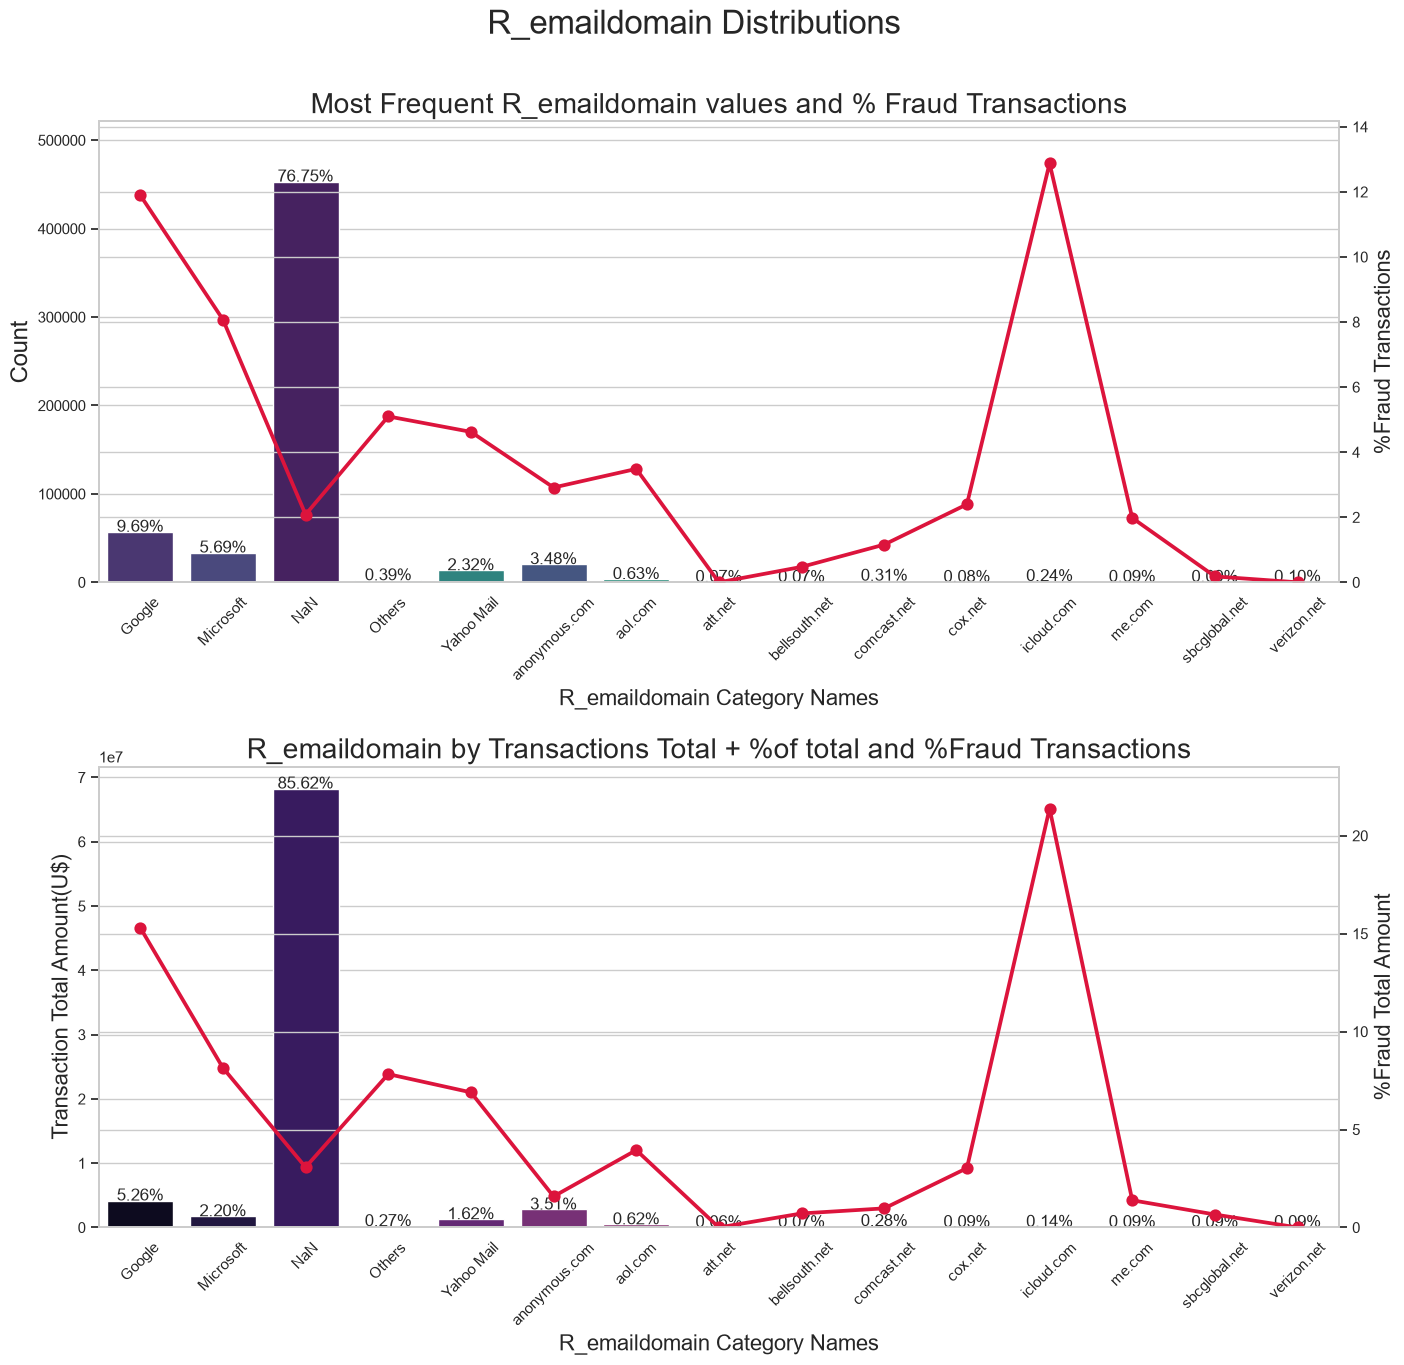

In [33]:
ploting_cnt_amt(df, 'R_emaildomain')

### M1–M9

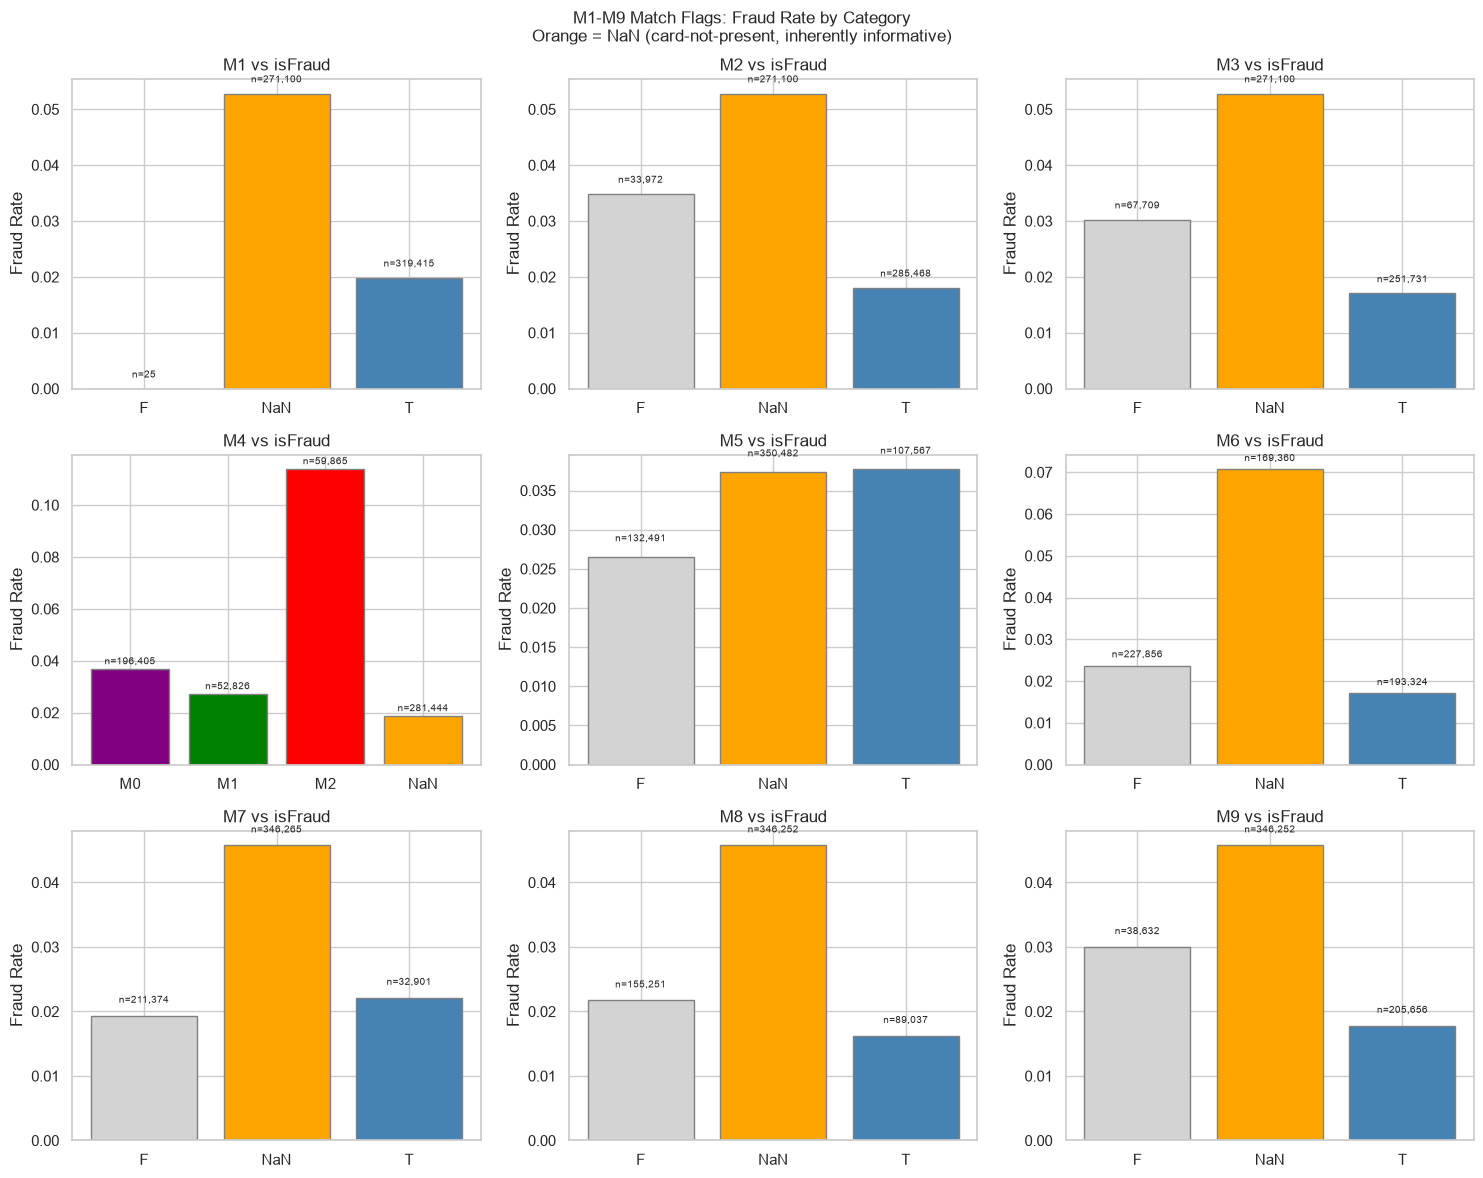

In [40]:
m_cols = [f'M{i}' for i in range(1, 10)]
df_m = df_train_transaction[m_cols + ['isFraud']].copy()
for col in m_cols:
    df_m[col] = df_m[col].fillna('NaN')

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
COLORS = {'T': 'steelblue', 'F': 'lightgray', 'NaN': 'orange', 'M0': 'purple', 'M1': 'green', 'M2': 'red'}

for i, col in enumerate(m_cols):
    fraud_rate = df_m.groupby(col)['isFraud'].mean().sort_index()
    count = df_m.groupby(col)['isFraud'].count()
    bar_colors = [COLORS.get(k, 'purple') for k in fraud_rate.index]
    axes[i].bar(fraud_rate.index, fraud_rate.values, color=bar_colors, edgecolor='gray')
    axes[i].set_title(f'{col} vs isFraud')
    axes[i].set_ylabel('Fraud Rate')
    for j, (cat, rate) in enumerate(fraud_rate.items()):
        axes[i].text(j, rate + 0.002, f'n={count[cat]:,}', ha='center', fontsize=7)

plt.suptitle('M1-M9 Match Flags: Fraud Rate by Category\nOrange = NaN (card-not-present, inherently informative)', fontsize=12)
plt.tight_layout()
plt.show()

### DeviceInfo

Many unique values, frequency encoding looks the best

In [41]:
df['DeviceInfo'].unique()

<ArrowStringArray>
[                             nan,  'SAMSUNG SM-G892A Build/NRD90M',
                     'iOS Device',                        'Windows',
                          'MacOS',          'SM-G930V Build/NRD90M',
        'BLADE A602 Build/MRA58K', 'XT1635-02 Build/NPN26.118-22-2',
                           'Z970',          'SM-N920V Build/NRD90M',
 ...
                             'IO',        'ASUS_X008D Build/NRD90M',
 'XT1635-02 Build/OPN27.76-12-22',           'SM-A520F Build/R16NW',
                          'G8142',                      'G630-U251',
                        'LG-K212',    'LDN-LX3 Build/HUAWEILDN-LX3',
                          'Z955A',                        'LG-E975']
Length: 1787, dtype: str

In [42]:
df.groupby('DeviceInfo', dropna=False)["TransactionID"].count().sort_values(ascending=False)

DeviceInfo
NaN            471874
Windows         47722
iOS Device      19782
MacOS           12573
Trident/7.0      7440
                ...  
SM-S320VL           1
SM-S120VL           1
LGL41C              1
LGL57BL             1
0PAJ5               1
Name: TransactionID, Length: 1787, dtype: int64

c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].map(df[col].value_counts())


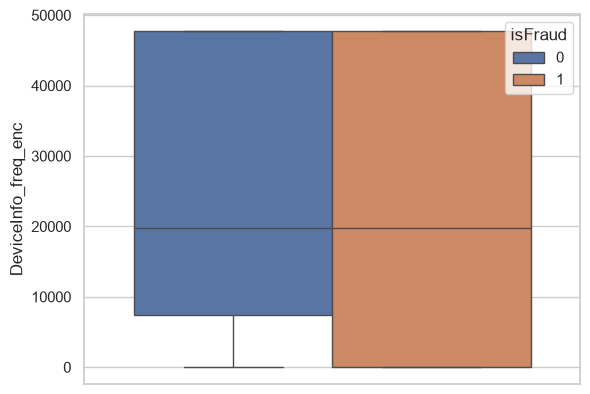

In [43]:
frequency_encode(df, "DeviceInfo", f'DeviceInfo_freq_enc')
sns.boxplot(data=df, y=f'DeviceInfo_freq_enc', hue='isFraud')
plt.show()

In [44]:
df.groupby('DeviceType', dropna=False)["TransactionID"].count().sort_values(ascending=False)

DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: TransactionID, dtype: int64

### DeviceType

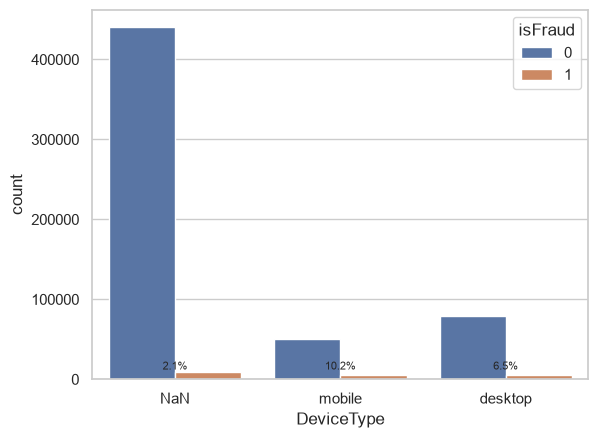

In [45]:
plot_col = df["DeviceType"].fillna('NaN')
ax = sns.countplot(x=plot_col, hue=df['isFraud'])
rates = df.groupby(plot_col, dropna=False)['isFraud'].mean()
categories = [t.get_text() for t in ax.get_xticklabels()]
for i, cat in enumerate(categories):
    rate = rates[cat] if cat in rates.index else 0
    ymax = ax.get_ylim()[1]
    ax.text(i, ymax * 0.02, f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=8)


### id_ columns overview (identity table)

id_01–id_11 are numeric network-signal columns; id_12–id_38 are categorical flags. Only ~144k of 590k transactions have any identity record, so all id_/Device columns carry a large structural NaN rate for the other ~450k rows.

In [46]:
id_cat = [f"id_{i}" for i in range(12, 39)]

for id in id_cat:
    print(f'{id}: {df[id].nunique()} unique values, NaN rate {df[id].isna().mean():.1%}')

id_12: 2 unique values, NaN rate 75.6%
id_13: 54 unique values, NaN rate 78.4%
id_14: 25 unique values, NaN rate 86.4%
id_15: 3 unique values, NaN rate 76.1%
id_16: 2 unique values, NaN rate 78.1%
id_17: 104 unique values, NaN rate 76.4%
id_18: 18 unique values, NaN rate 92.4%
id_19: 522 unique values, NaN rate 76.4%
id_20: 394 unique values, NaN rate 76.4%
id_21: 490 unique values, NaN rate 99.1%
id_22: 25 unique values, NaN rate 99.1%
id_23: 3 unique values, NaN rate 99.1%
id_24: 12 unique values, NaN rate 99.2%
id_25: 341 unique values, NaN rate 99.1%
id_26: 95 unique values, NaN rate 99.1%
id_27: 2 unique values, NaN rate 99.1%
id_28: 2 unique values, NaN rate 76.1%
id_29: 2 unique values, NaN rate 76.1%
id_30: 75 unique values, NaN rate 86.9%
id_31: 130 unique values, NaN rate 76.2%
id_32: 4 unique values, NaN rate 86.9%
id_33: 260 unique values, NaN rate 87.6%
id_34: 4 unique values, NaN rate 86.8%
id_35: 2 unique values, NaN rate 76.1%
id_36: 2 unique values, NaN rate 76.1%
id_3

c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].map(df[col].value_counts())
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].map(df[col].value_counts())
c:\Users\zheng\VSCProjects\Fraud-Detection-Agent\src\features\utils.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

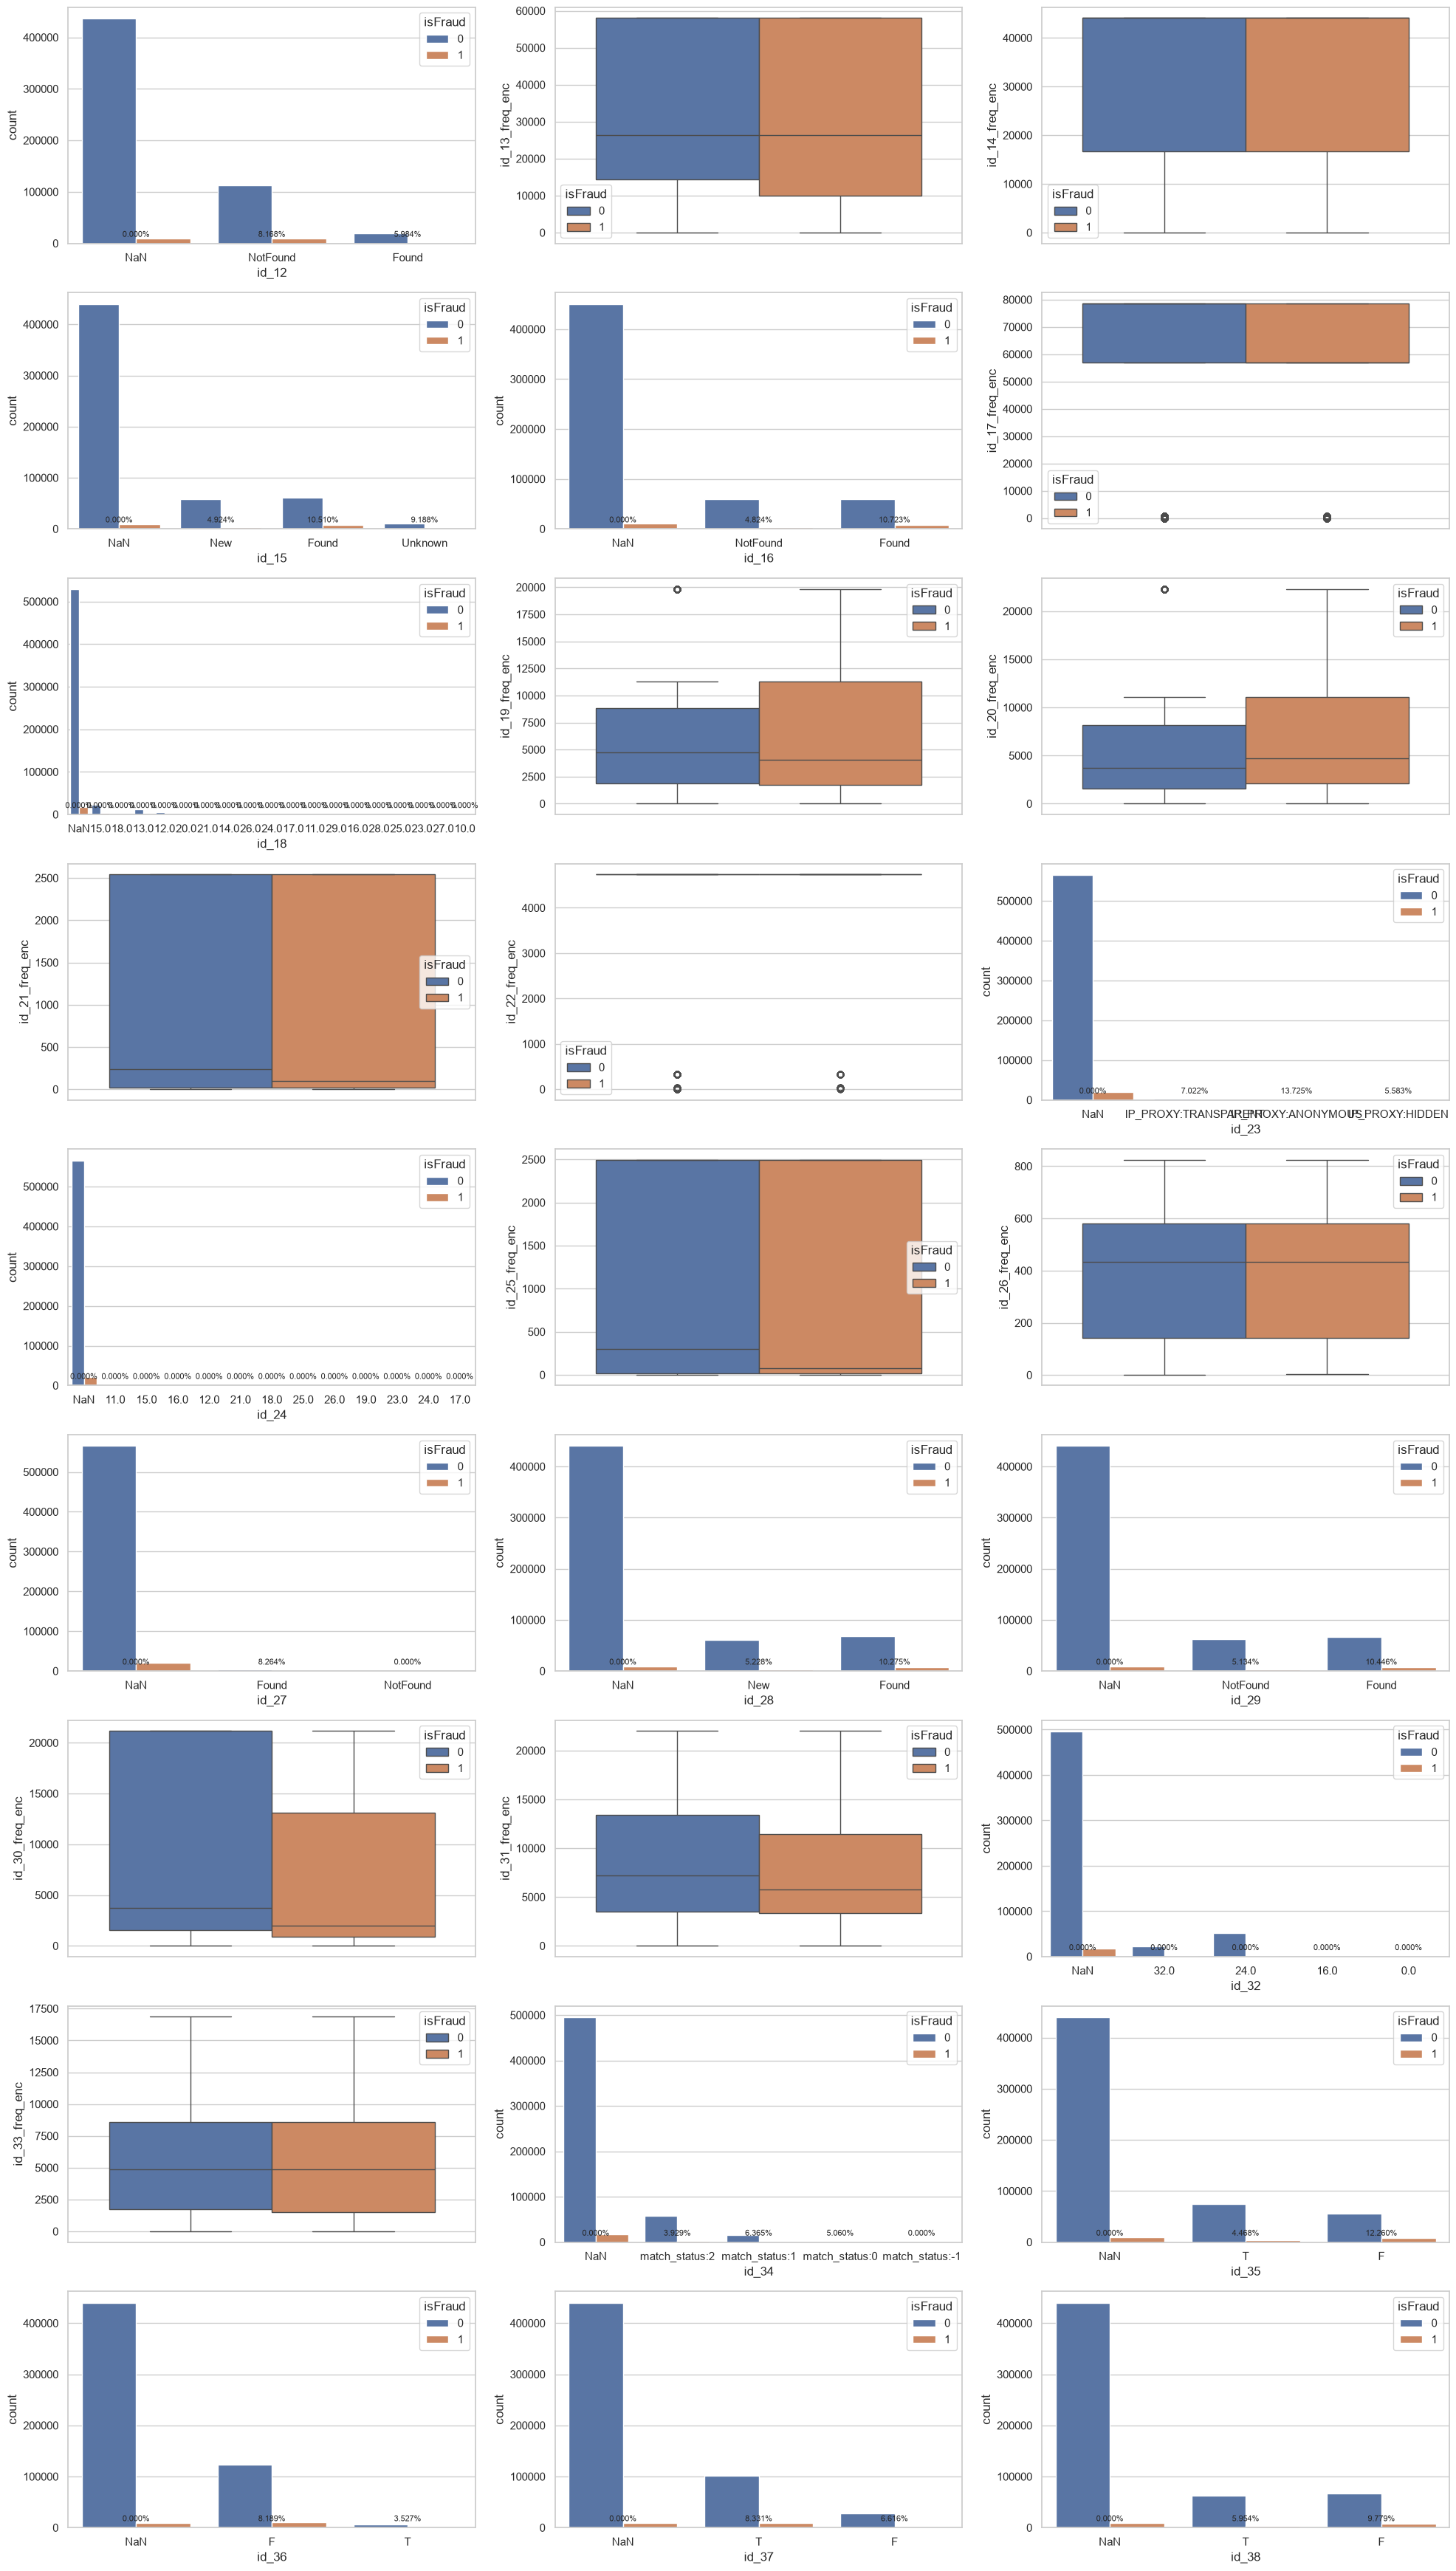

In [47]:
fig, axes = plt.subplots(9,3, figsize=(20, 35))

for ax, curr_col in zip(axes.flat,id_cat):
    if len(df[curr_col].value_counts()) > 20:
        frequency_encode(df, curr_col, f"{curr_col}_freq_enc")
        sns.boxplot(data=df, y=f"{curr_col}_freq_enc", hue="isFraud", ax=ax)
    else:
        plot_col = df[curr_col].fillna("NaN")
        sns.countplot(x=plot_col, hue=df["isFraud"], ax=ax)
        rates = df.groupby(curr_col, dropna=False)["isFraud"].mean()
        categories = [t.get_text() for t in ax.get_xticklabels()]

        for i, cat in enumerate(categories):
            # cat is a string from get_text(); match dtype if rates index isn't string
            key = cat
            rate = rates[key] if key in rates.index else 0
            ymax = ax.get_ylim()[1]
            ax.text(i, ymax * 0.02, f'{rate*100:.3f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()



In [48]:
df.id_32.value_counts()

id_32
24.0    53071
32.0    24428
16.0       81
0.0         6
Name: count, dtype: int64

In [50]:
id_numeric = [c for c in df_train_identity.columns if c.startswith('id_') and pd.api.types.is_numeric_dtype(df_train_identity[c]) and df_train_identity[c].nunique() > 20]
id_categorical = [c for c in df_train_identity.columns if c.startswith('id_') and c not in id_numeric]
print(f'Numeric id_ columns ({len(id_numeric)}): {id_numeric}')
print(f'Categorical id_ columns ({len(id_categorical)}): {id_categorical}')

Numeric id_ columns (19): ['id_01', 'id_02', 'id_03', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_19', 'id_20', 'id_21', 'id_22', 'id_25', 'id_26']
Categorical id_ columns (19): ['id_04', 'id_12', 'id_15', 'id_16', 'id_18', 'id_23', 'id_24', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


In [51]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,card1_freq_enc,card2_freq_enc,card3_freq_enc,card5_freq_enc,addr1_freq_enc,addr2_freq_enc,DeviceInfo_freq_enc,id_13_freq_enc,id_14_freq_enc,id_17_freq_enc,id_19_freq_enc,id_20_freq_enc,id_21_freq_enc,id_22_freq_enc,id_25_freq_enc,id_26_freq_enc,id_30_freq_enc,id_31_freq_enc,id_33_freq_enc
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## 3. TransactionDT — Time Analysis

`TransactionDT` is **not** a real timestamp. It is seconds elapsed since an unknown reference epoch.
- Training set spans ~182 days; the (unlabeled) Kaggle test set is the next ~90 days.
- We derive `hour_of_day` and `day_of_week` to find when fraud peaks.
- **CV implication**: must use time-based validation split. Random k-fold leaks future data and inflates AUPRC by ~0.01-0.02.

C:\Users\zheng\AppData\Local\Temp\ipykernel_5736\2416912119.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day'] = df['TransactionDT'] // 86400
C:\Users\zheng\AppData\Local\Temp\ipykernel_5736\2416912119.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour_of_day'] = (df['TransactionDT'] // 3600) % 24
C:\Users\zheng\AppData\Local\Temp\ipykernel_5736\2416912119.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  C

Training spans day 1 to 182 (181 days total)


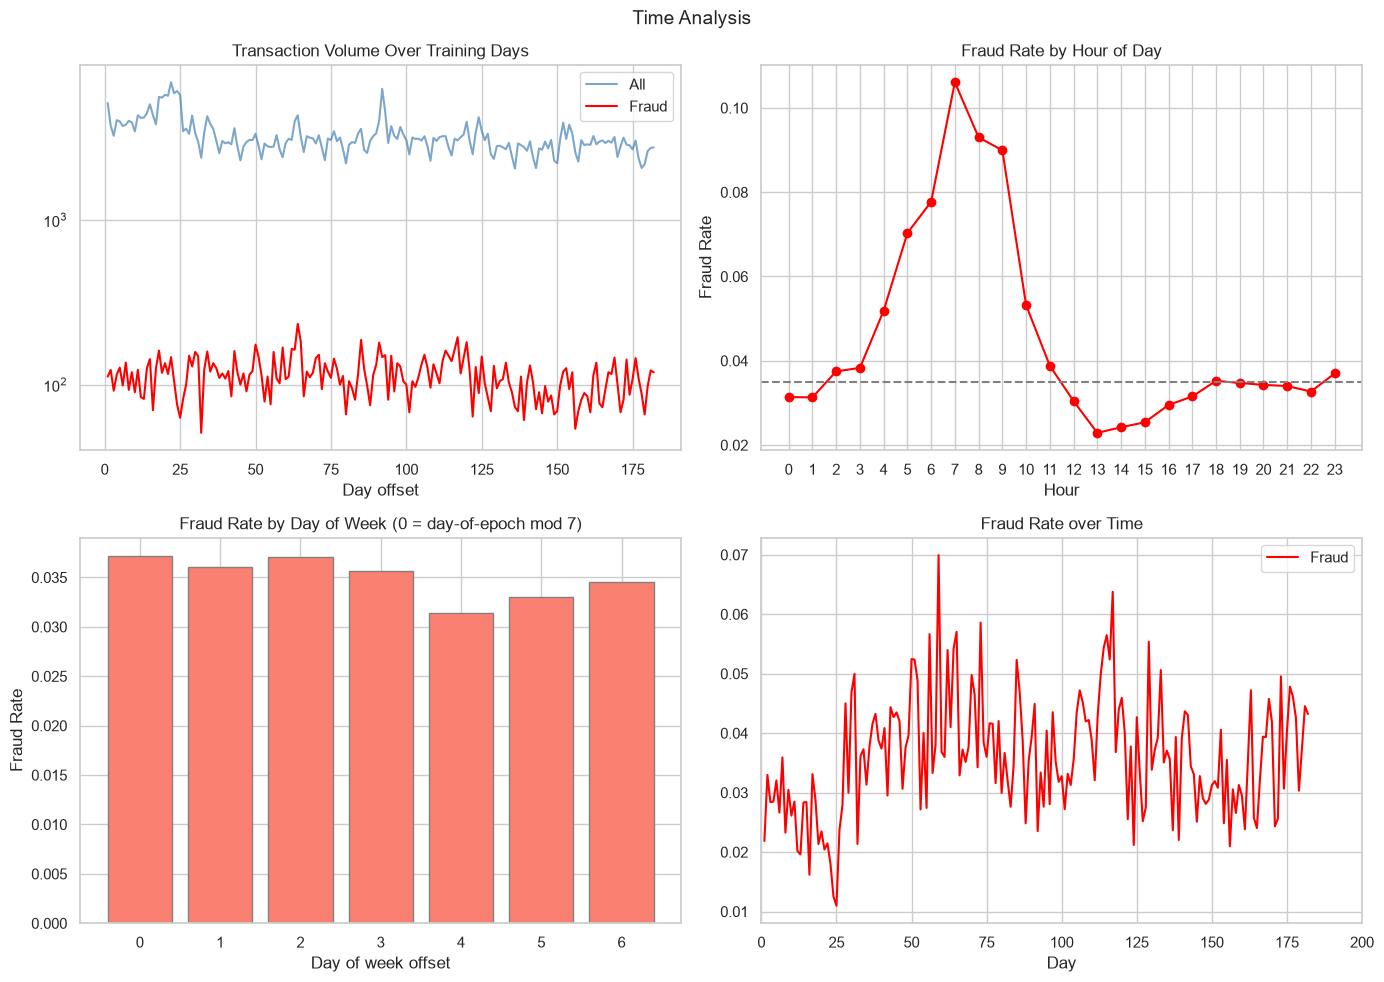

In [55]:
df['day'] = df['TransactionDT'] // 86400
df['hour_of_day'] = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // 86400) % 7

print(f"Training spans day {df['day'].min()} to {df['day'].max()} ({df['day'].max() - df['day'].min()} days total)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

daily_all = df.groupby('day').size()
daily_fraud = df[df['isFraud'] == 1].groupby('day').size()
axes[0, 0].plot(daily_all.index, daily_all.values, color='steelblue', alpha=0.7, label='All')
axes[0, 0].plot(daily_fraud.index, daily_fraud.values, color='red', label='Fraud')
axes[0, 0].set_title('Transaction Volume Over Training Days')
axes[0, 0].set_xlabel('Day offset')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()

hourly = df.groupby('hour_of_day')['isFraud'].mean()
axes[0, 1].plot(hourly.index, hourly.values, marker='o', color='red')
axes[0, 1].set_title('Fraud Rate by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Fraud Rate')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].axhline(y=df['isFraud'].mean(), color='gray', linestyle='--', label='Overall Fraud Rate')

dow = df.groupby('day_of_week')['isFraud'].mean()
axes[1, 0].bar(dow.index, dow.values, color='salmon', edgecolor='gray')
axes[1, 0].set_title('Fraud Rate by Day of Week (0 = day-of-epoch mod 7)')
axes[1, 0].set_xlabel('Day of week offset')
axes[1, 0].set_ylabel('Fraud Rate')

fraud_rate = df.groupby('day')['isFraud'].mean()
axes[1, 1].plot(fraud_rate.index, fraud_rate.values, color='red', label='Fraud')
axes[1, 1].set_title('Fraud Rate over Time')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_xlim(0, 200)
axes[1, 1].legend()

plt.suptitle('Time Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Numerical Feature Distributions

`TransactionAmt`, `dist`, `C1-C14`, `D1-D15` and the numeric `id_` columns — **excluding V-columns** (339 of
them, only useful in aggregate; see section 6).

### TransactionAmt


<Axes: xlabel='isFraud', ylabel='TransactionAmt'>

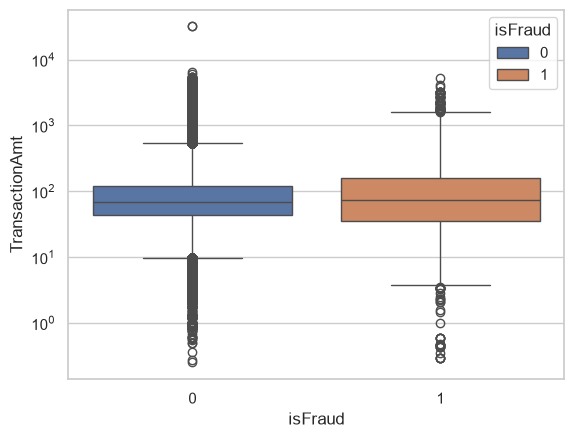

In [37]:
sns.boxplot(data=df, y='TransactionAmt', x='isFraud', hue='isFraud', log_scale=True)

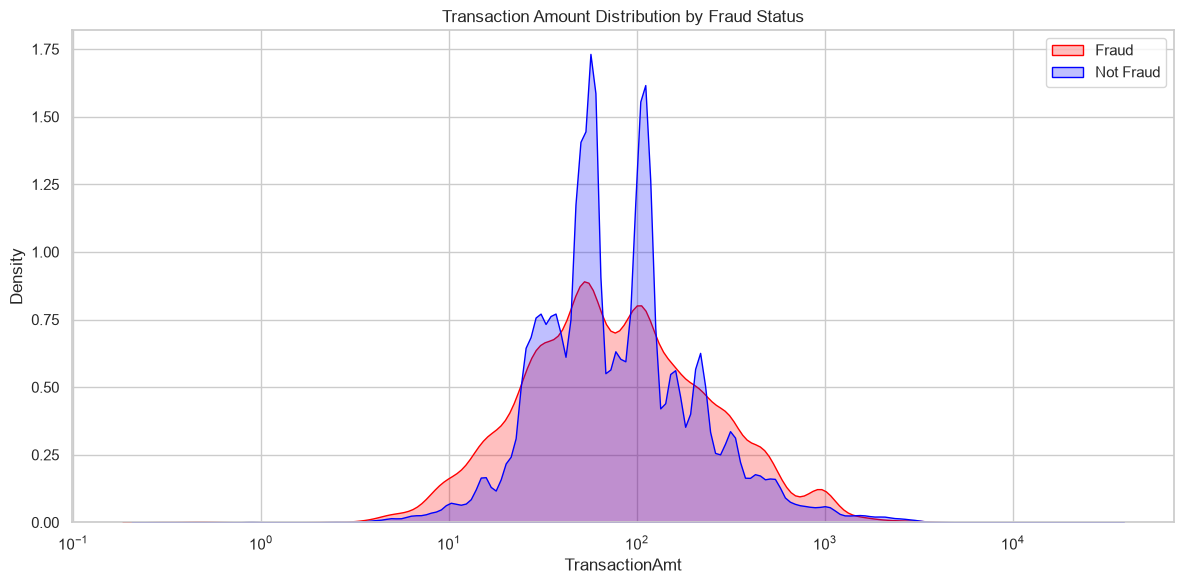

In [43]:
fig, ax = plt.subplots(figsize=(12,6))
sns.kdeplot(data=df[df['isFraud'] == 1], x='TransactionAmt', log_scale=True, ax=ax, label='Fraud', color='red', fill=True)
sns.kdeplot(data=df[df['isFraud'] == 0], x='TransactionAmt', log_scale=True, ax=ax, label='Not Fraud', color='blue', fill=True)
ax.set_title('Transaction Amount Distribution by Fraud Status')
ax.legend()
plt.tight_layout()
plt.show()

Standalone, transactionAmt doesnt seem that useful, but with other variables like productCD, it helps to split it more.

<Axes: xlabel='ProductCD', ylabel='TransactionAmt'>

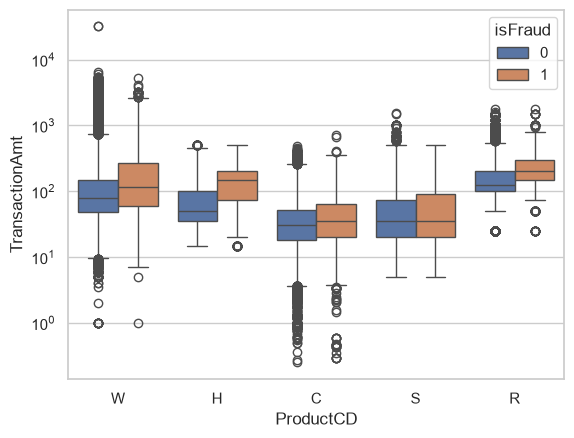

In [44]:
sns.boxplot(data=df, y='TransactionAmt', x='ProductCD', hue='isFraud', log_scale=True)

## Dist columns

In [22]:
print(f"dist 1 nan rates: {df['dist1'].isna().mean()}")
print(df['dist1'].describe())
print(f"dist 2 nan rates: {df['dist2'].isna().mean()}")
print(df['dist2'].describe())

dist 1 nan rates: 0.596523520845328
count    238269.000000
mean        118.502180
std         371.872026
min           0.000000
25%           3.000000
50%           8.000000
75%          24.000000
max       10286.000000
Name: dist1, dtype: float64
dist 2 nan rates: 0.9362837403054831
count    37627.000000
mean       231.855423
std        529.053494
min          0.000000
25%          7.000000
50%         37.000000
75%        206.000000
max      11623.000000
Name: dist2, dtype: float64


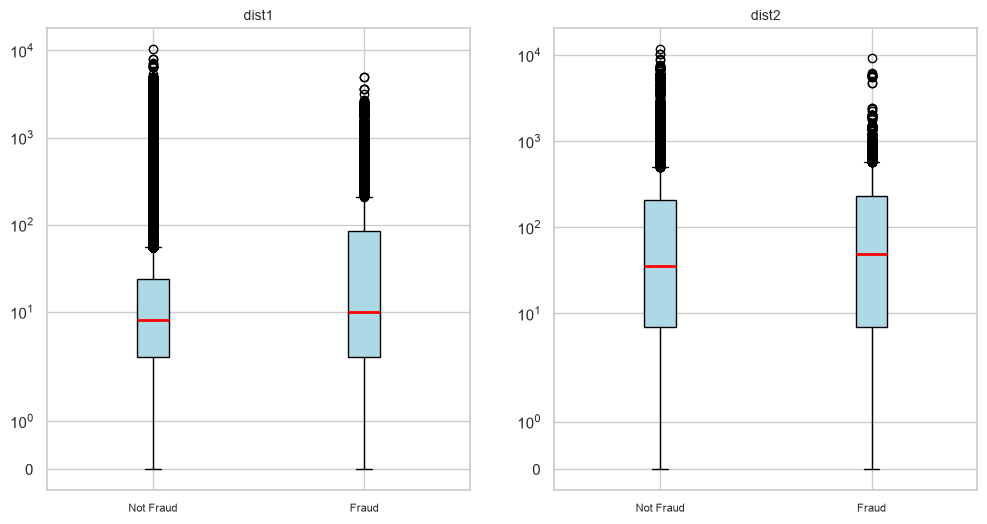

In [23]:
dist_cols = ['dist1', 'dist2']
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, col in enumerate(dist_cols):
    legit = df.loc[df['isFraud'] == 0, col].dropna()
    fraud = df.loc[df['isFraud'] == 1, col].dropna()
    axes[i].boxplot([legit, fraud], tick_labels=['Not Fraud', 'Fraud'],
                    patch_artist=True, boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_yscale('symlog')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)

## C columns

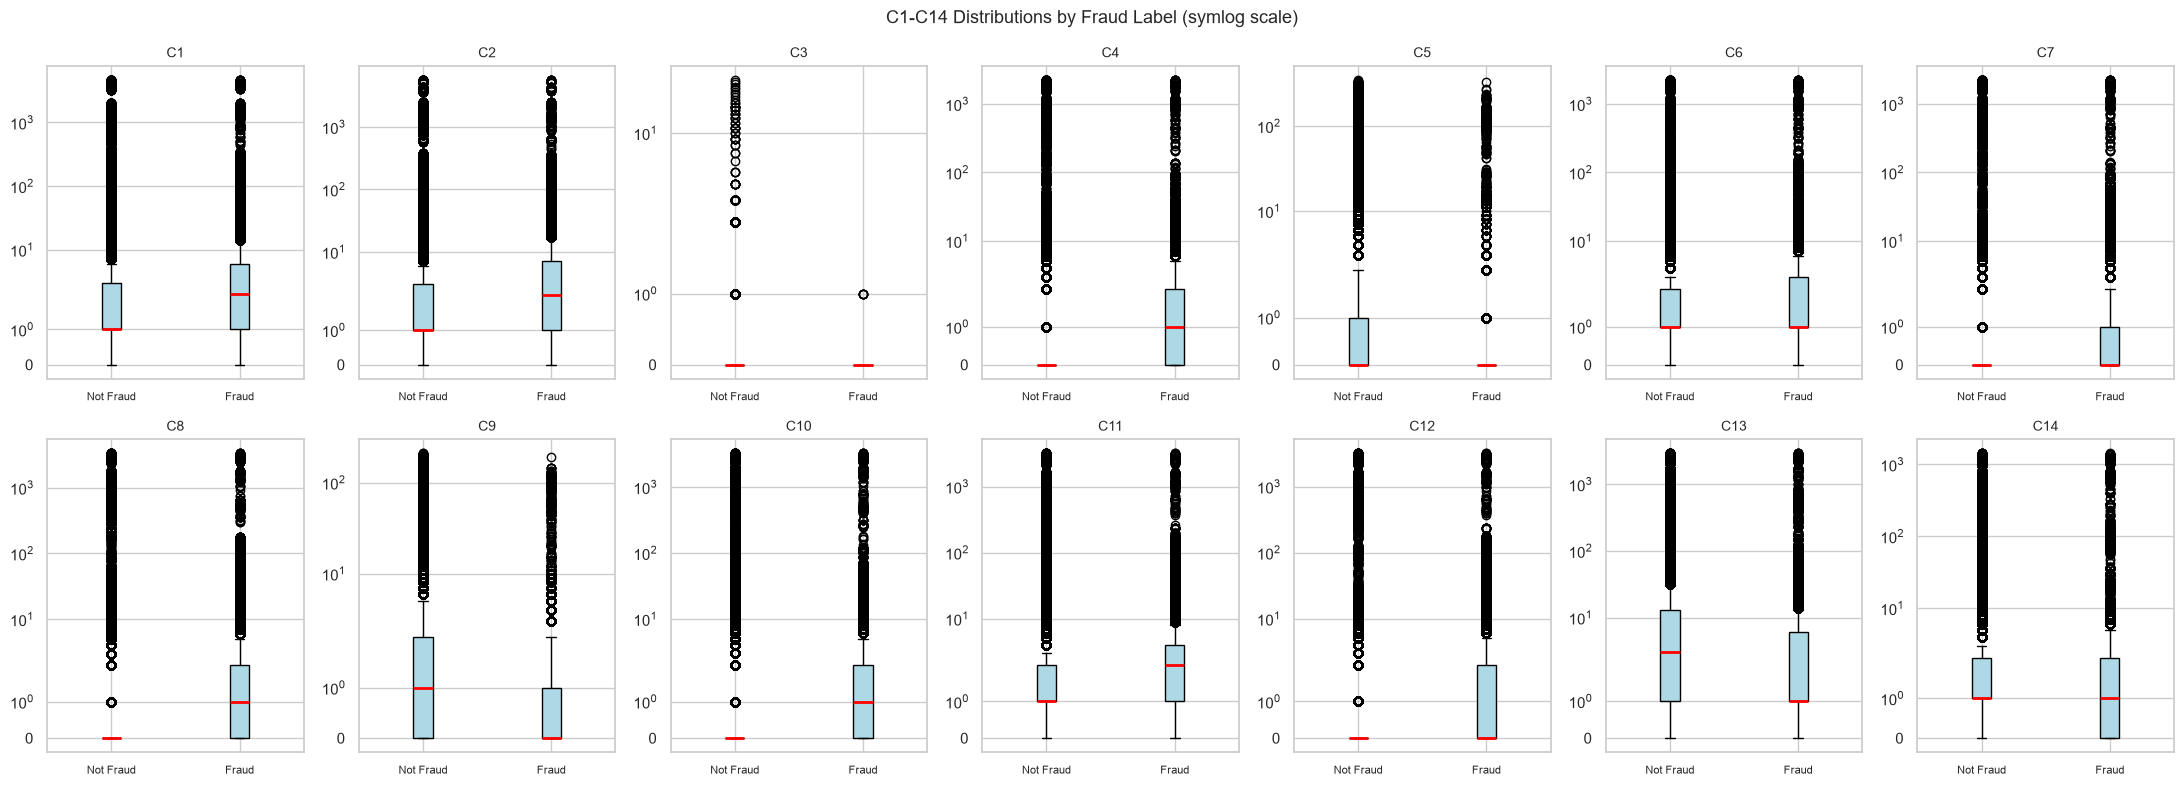

In [20]:
c_cols = [f'C{i}' for i in range(1, 15)]
fig, axes = plt.subplots(2, 7, figsize=(22, 8))
axes = axes.flatten()
for i, col in enumerate(c_cols):
    data_legit = df_train_transaction.loc[df_train_transaction['isFraud'] == 0, col].dropna()
    data_fraud = df_train_transaction.loc[df_train_transaction['isFraud'] == 1, col].dropna()
    axes[i].boxplot([data_legit, data_fraud], tick_labels=['Not Fraud', 'Fraud'],
                    patch_artist=True, boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_yscale('symlog')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)
plt.suptitle('C1-C14 Distributions by Fraud Label (symlog scale)', fontsize=13)
plt.tight_layout()
plt.show()

D-column NaN rates:
D7     0.934099
D13    0.895093
D14    0.894695
D12    0.890410
D6     0.876068
D8     0.873123
D9     0.873123
D5     0.524674
D2     0.475492
D11    0.472935
D3     0.445149
D4     0.286047
D15    0.150901
D10    0.128733
D1     0.002149


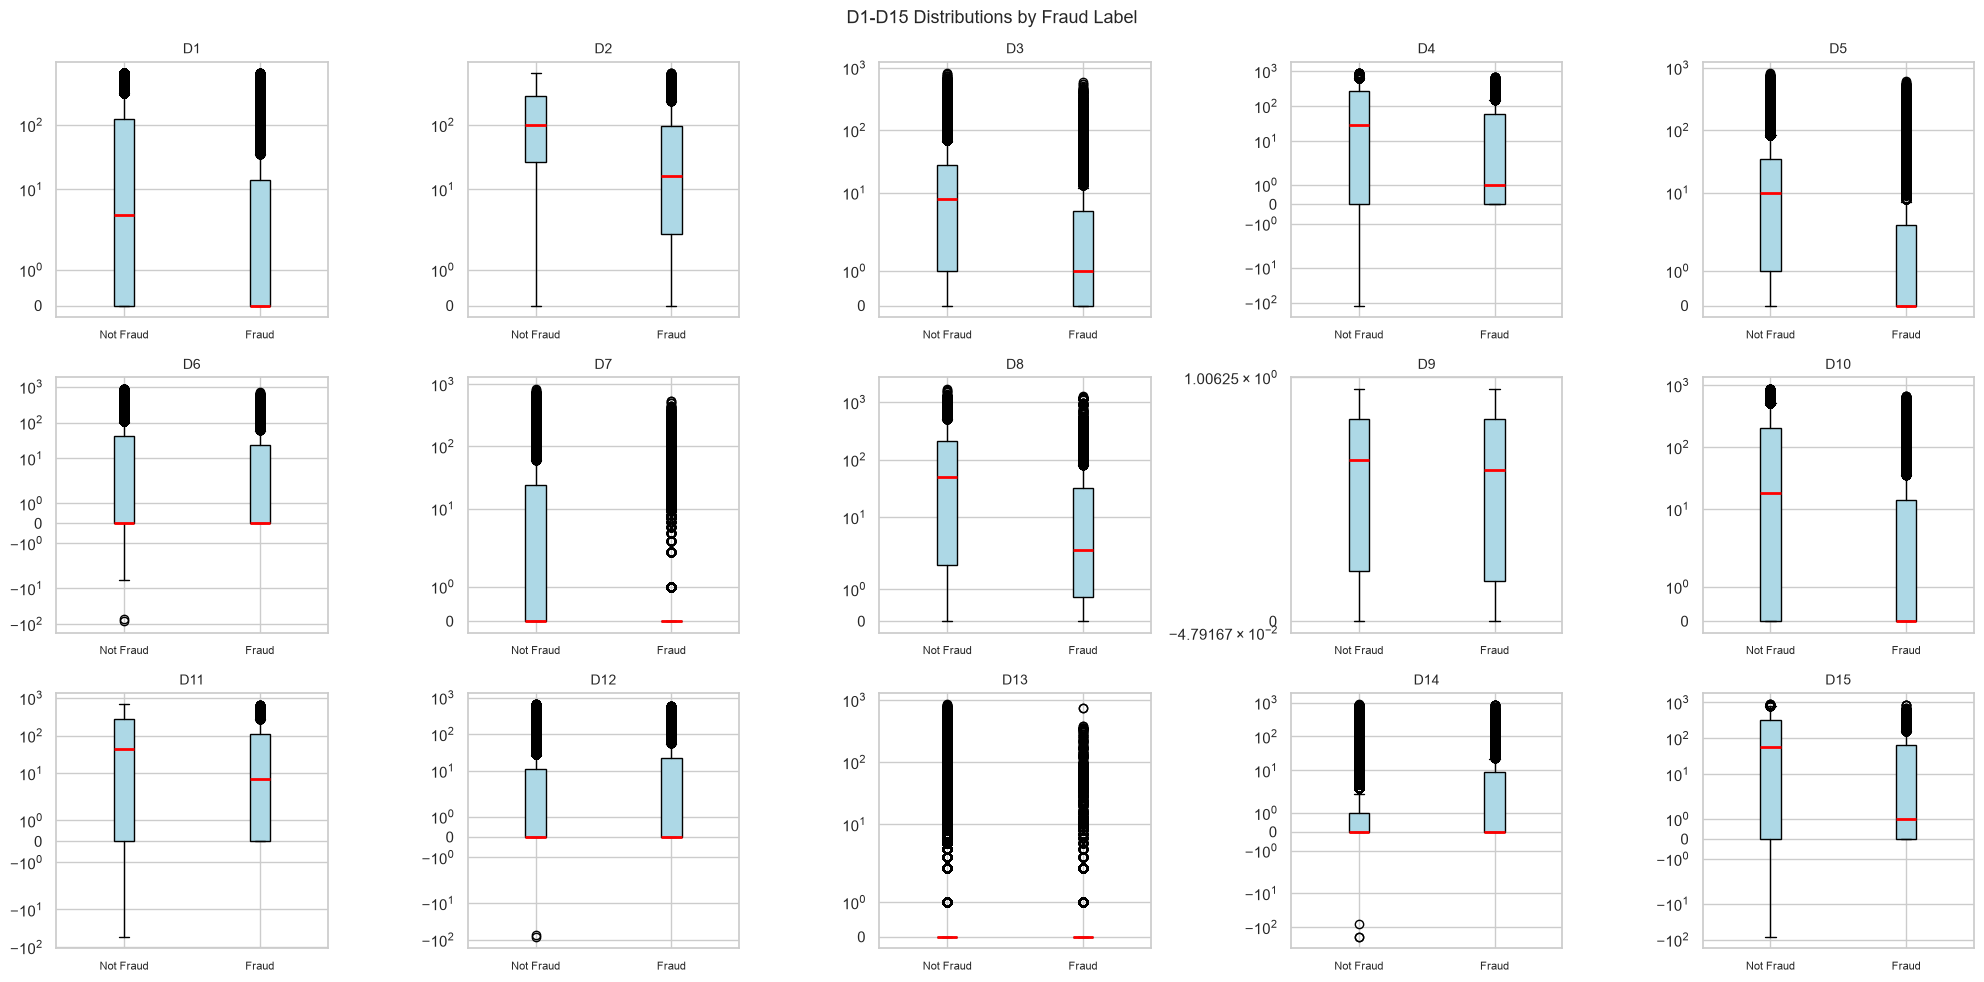

In [4]:
d_cols = [f'D{i}' for i in range(1, 16)]
d_nan_rates = df_train_transaction[d_cols].isna().mean().sort_values(ascending=False)
print('D-column NaN rates:')
print(d_nan_rates.to_string())

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(d_cols):
    legit = df_train_transaction.loc[df_train_transaction['isFraud'] == 0, col].dropna()
    fraud = df_train_transaction.loc[df_train_transaction['isFraud'] == 1, col].dropna()
    axes[i].boxplot([legit, fraud], tick_labels=['Not Fraud', 'Fraud'],
                    patch_artist=True, boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_yscale('symlog')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)
plt.suptitle('D1-D15 Distributions by Fraud Label', fontsize=13)
plt.tight_layout()
plt.show()

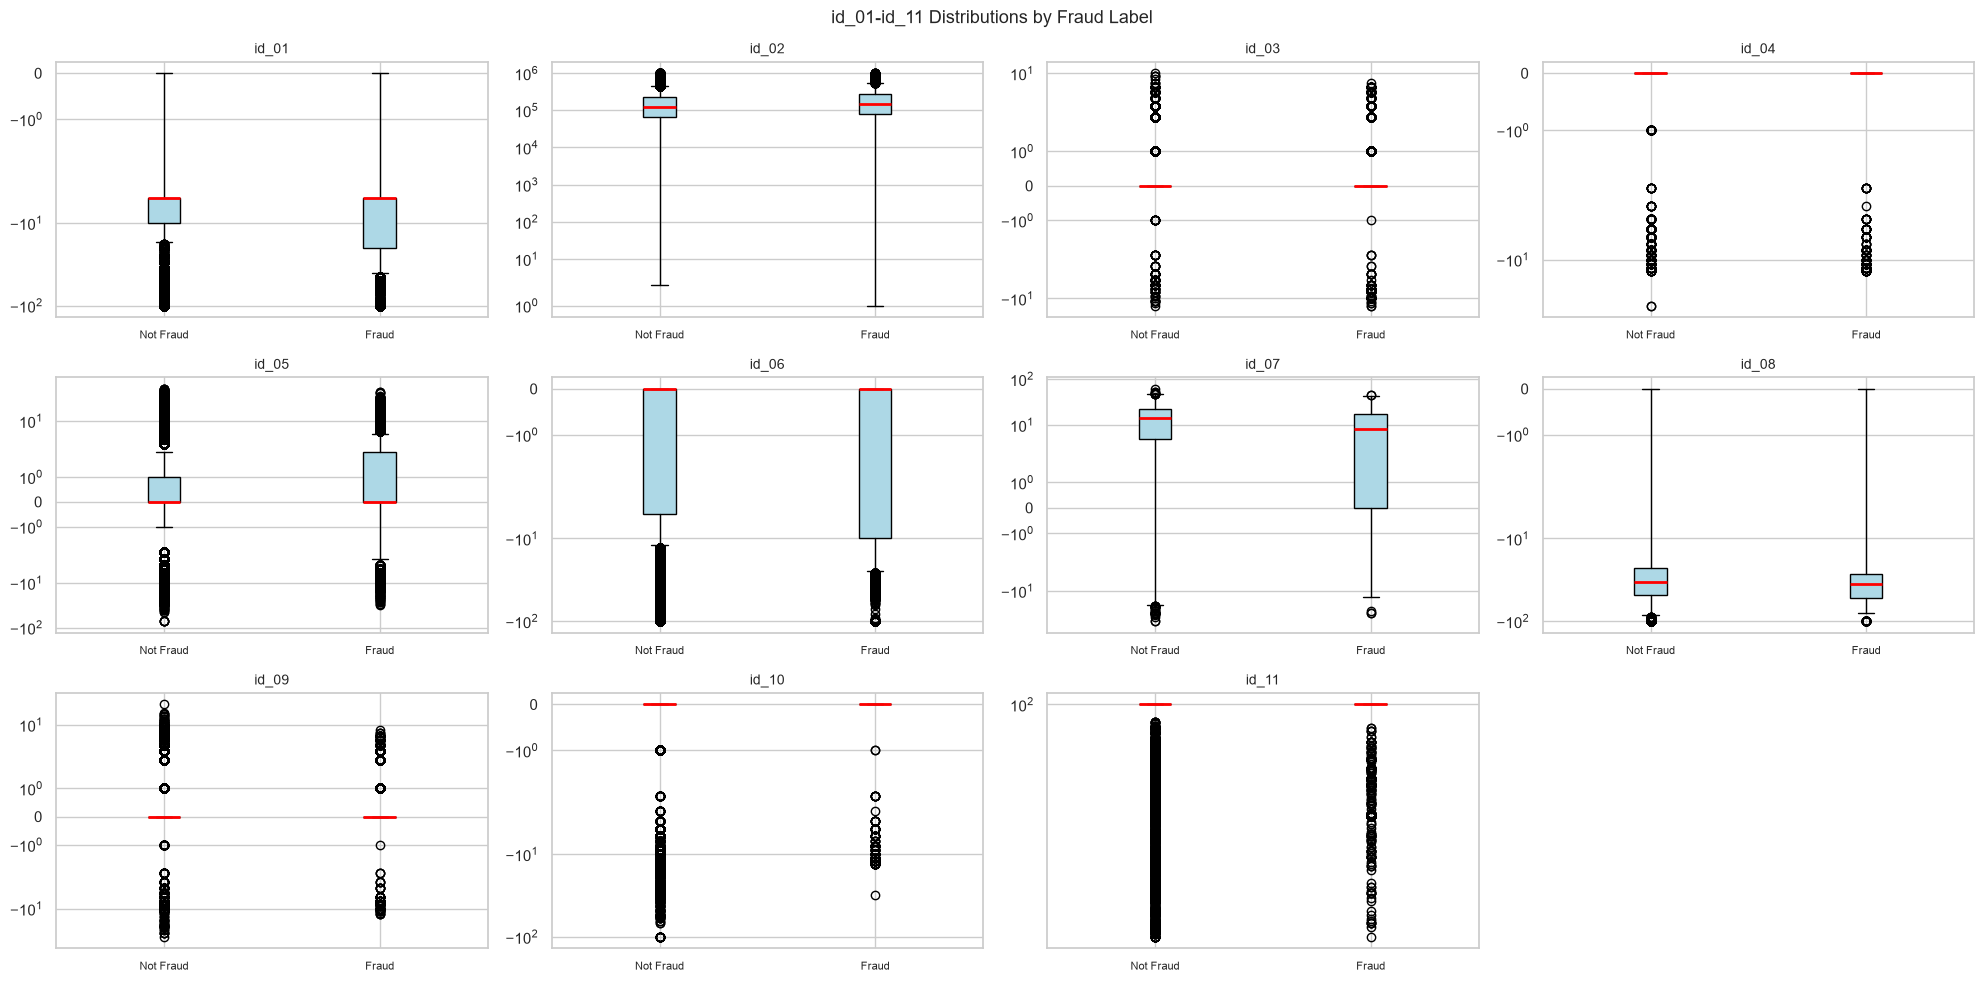

In [11]:
id_1_11 = [f'id_0{i}' if i<10 else f'id_{i}' for i in range(1, 12)]
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(id_1_11):
    legit = df.loc[df_train_transaction['isFraud'] == 0, col].dropna()
    fraud = df.loc[df_train_transaction['isFraud'] == 1, col].dropna()
    axes[i].boxplot([legit, fraud], tick_labels=['Not Fraud', 'Fraud'],
                    patch_artist=True, boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_yscale('symlog')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelsize=8)
fig.delaxes(axes[-1])  # Remove the last empty subplot
plt.suptitle('id_01-id_11 Distributions by Fraud Label', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Correlation & Redundancy (non-V columns)

Goal: identify redundant columns among C, D, and other non-V numeric features (|r| > 0.95) so we
drop the more-missing column of each pair. This feeds `HIGH_CORR_COLS` in `preprocess.py`.

> V-columns are excluded here — see section 6 for why they're handled by NaN-pattern clustering + PCA instead.

In [57]:
numeric_without_v = ['TransactionAmt',
 'card1_freq_enc', 'card2_freq_enc', 'card3_freq_enc', 'card5_freq_enc',
 'addr1_freq_enc', 'addr2_freq_enc',
 'DeviceInfo_freq_enc',
 'id_13_freq_enc', 'id_14_freq_enc', 'id_17_freq_enc', 'id_19_freq_enc', 'id_20_freq_enc', 'id_21_freq_enc', 
 'id_22_freq_enc', 'id_25_freq_enc', 'id_26_freq_enc', 'id_30_freq_enc', 'id_31_freq_enc', 'id_33_freq_enc',
 'day', 'hour_of_day', 'day_of_week',
 'dist1', 'dist2',
 'C1', 'C2', 'C3','C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14','D15',
 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11'
]

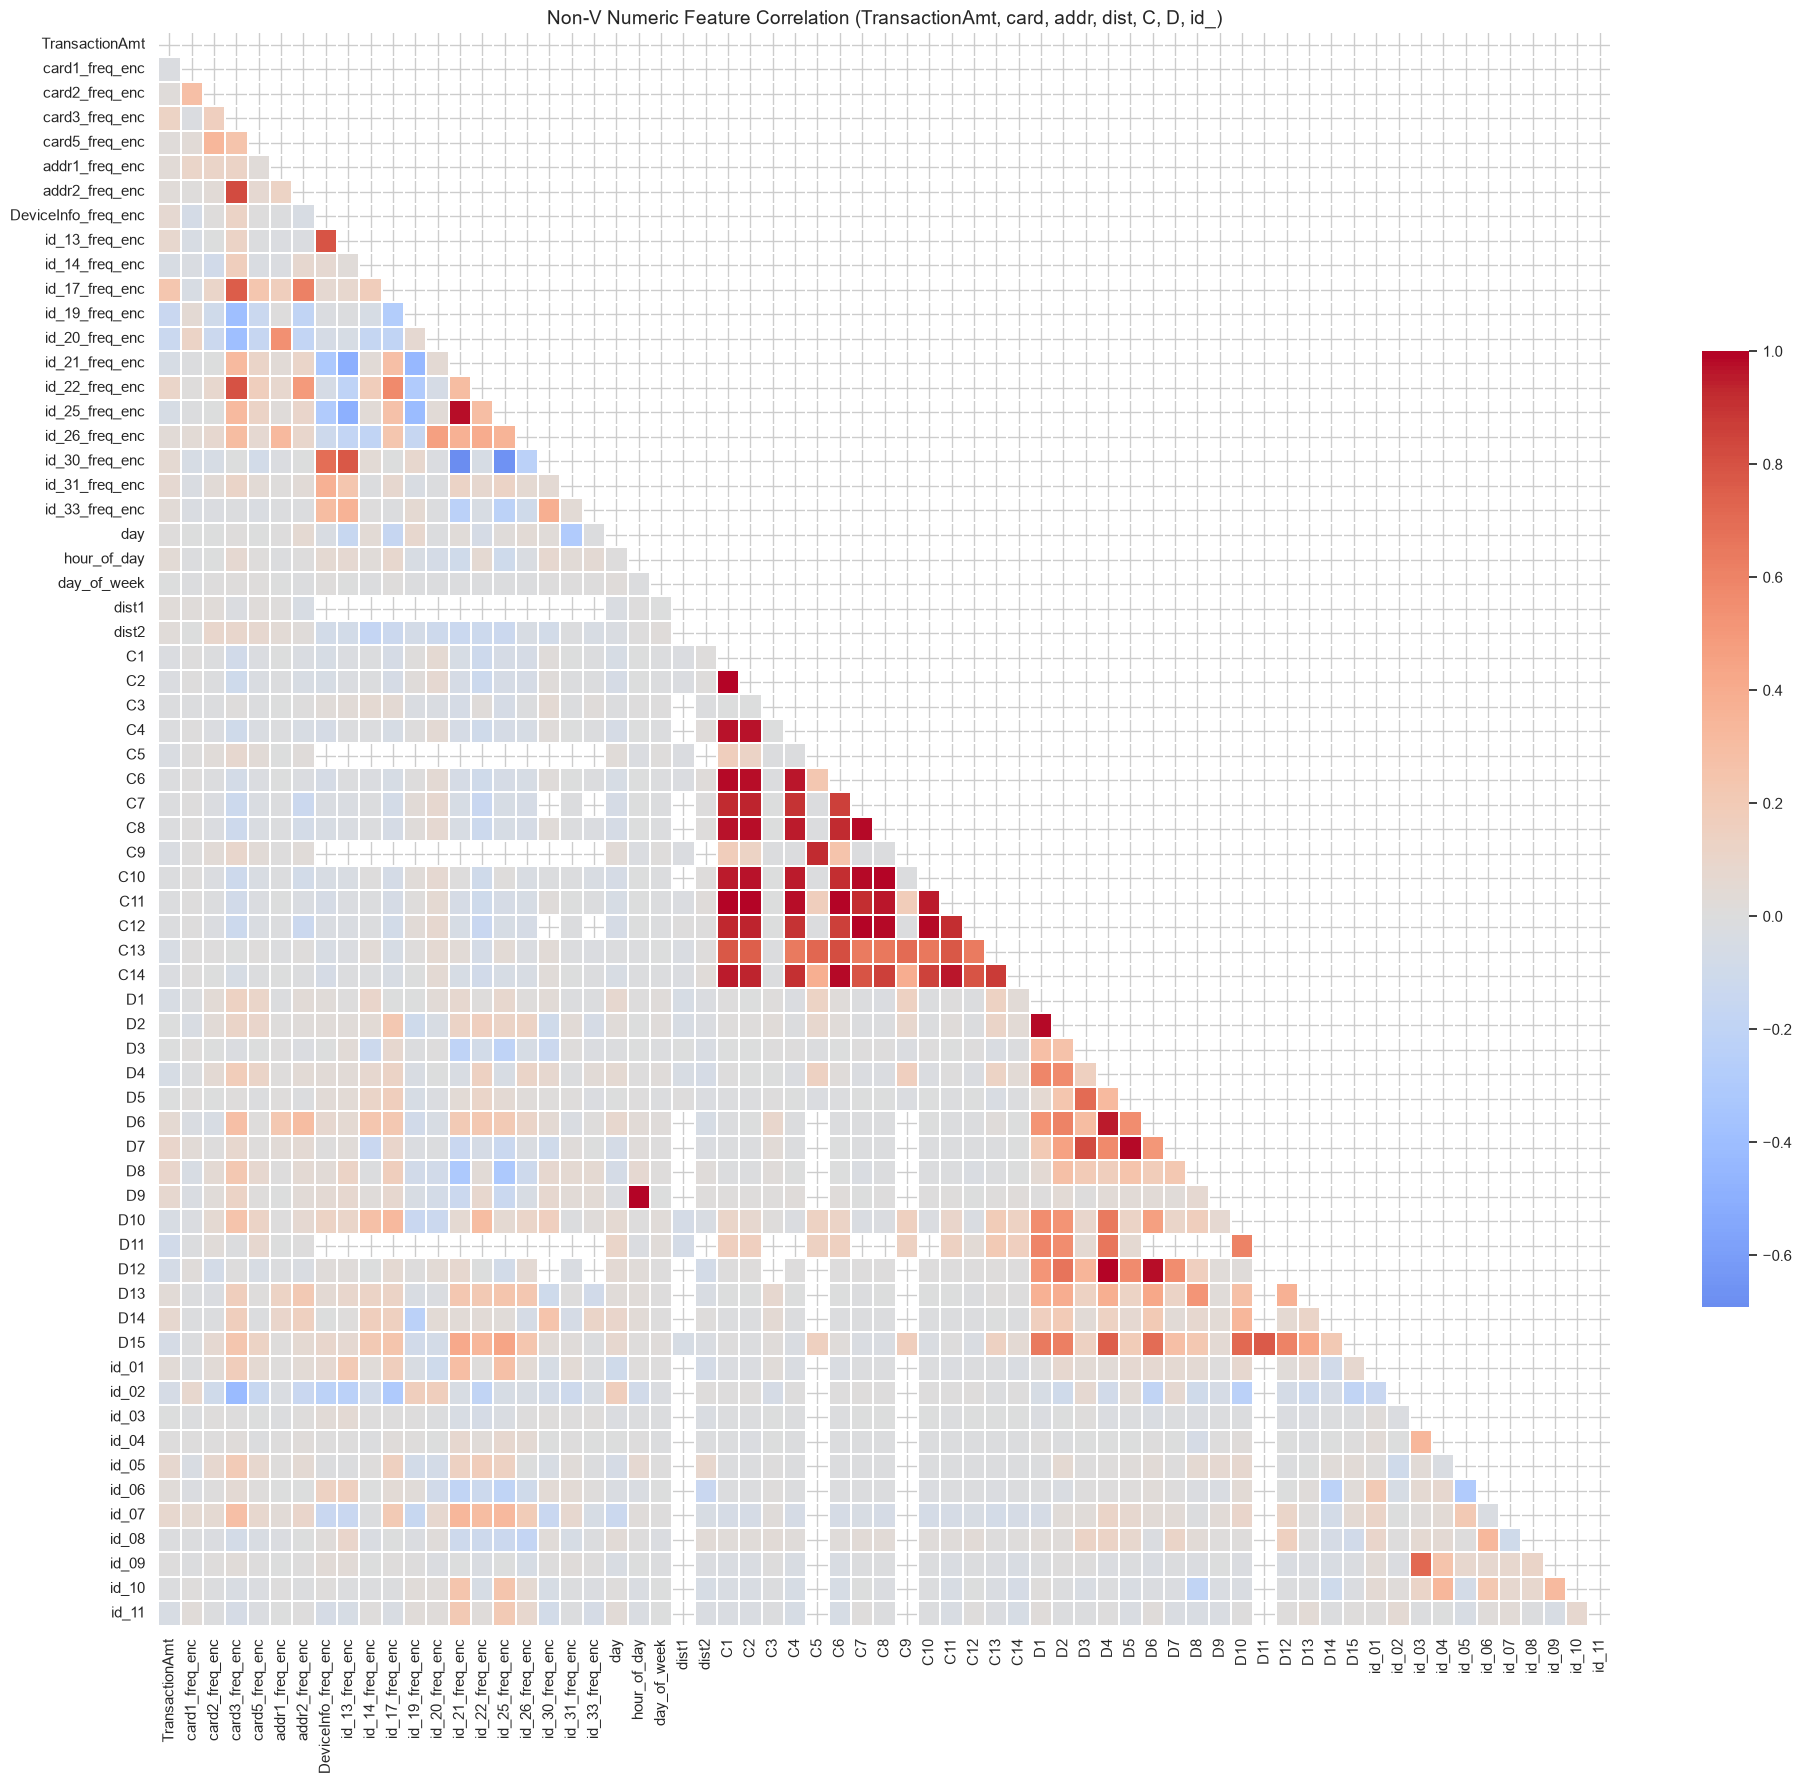

In [59]:
corr = df[numeric_without_v].corr()

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.3, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.6})
ax.set_title('Non-V Numeric Feature Correlation (TransactionAmt, card, addr, dist, C, D, id_)', fontsize=14)
plt.tight_layout()
plt.show()

In [60]:
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if pd.notna(r) and abs(r) > 0.95:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(float(r), 4)))
high_corr_pairs.sort(key=lambda x: -abs(x[2]))

print(f'High-correlation non-V pairs (|r| > 0.95): {len(high_corr_pairs)}')
for a, b, r in high_corr_pairs:
    print(f'  {a} ~ {b}: {r}')

High-correlation non-V pairs (|r| > 0.95): 34
  hour_of_day ~ D9: 1.0
  D4 ~ D12: 1.0
  C7 ~ C12: 0.9995
  C8 ~ C10: 0.997
  C1 ~ C11: 0.9965
  C1 ~ C2: 0.9951
  C2 ~ C11: 0.9939
  C6 ~ C11: 0.9911
  D5 ~ D7: 0.9865
  C7 ~ C10: 0.9851
  C6 ~ C14: 0.9842
  C10 ~ C12: 0.9838
  C7 ~ C8: 0.983
  C8 ~ C12: 0.983
  C1 ~ C6: 0.9822
  D1 ~ D2: 0.9813
  id_21_freq_enc ~ id_25_freq_enc: 0.9775
  D6 ~ D12: 0.9768
  C2 ~ C8: 0.9759
  C2 ~ C6: 0.9748
  C4 ~ C11: 0.9745
  C2 ~ C4: 0.9721
  C2 ~ C10: 0.9706
  C1 ~ C4: 0.9678
  C1 ~ C8: 0.9677
  C8 ~ C11: 0.9627
  C11 ~ C14: 0.9625
  C4 ~ C6: 0.9623
  C4 ~ C8: 0.96
  C1 ~ C10: 0.9582
  D4 ~ D6: 0.957
  C10 ~ C11: 0.9561
  C4 ~ C10: 0.9525
  C1 ~ C14: 0.9518


In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Isolate the exact same features you used for your heatmap
X = df[numeric_without_v].copy()

# 2. Handle missing values (CRITICAL for statsmodels)
# You can choose to impute (e.g., X.fillna(X.median())) if dropping loses too much data
X = X.fillna(X.median())

# 3. Add a constant (CRITICAL for accurate VIF)
X_with_const = add_constant(X)

# 4. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i) 
    for i in range(X_with_const.shape[1])
]

# 5. Clean up the output: remove the constant and sort by highest VIF
vif_data = vif_data[vif_data["Feature"] != "const"]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# Display the top correlated variables
print(vif_data.head(20))

           Feature          VIF
0              C12  4279.638350
1               C7  3011.717855
2              C11  2338.487712
3               C8  1661.712009
4               C4   880.571355
5               C6   646.214188
6              C10   557.808259
7               C1   529.487248
8              C14   371.664030
9               C2   363.385443
10              C9    66.241766
11             C13    46.071343
12  id_21_freq_enc    33.243318
13  id_25_freq_enc    32.961239
14              C5    16.202125
15              D1     9.459659
16              D2     7.553719
17  card3_freq_enc     3.628162
18             D15     3.305166
19              D6     2.994314


In [66]:
# Resolve each pair by dropping whichever column is more often missing (less complete).
nan_rate_nv = df[numeric_without_v].isna().mean()
drop = set()
for a, b, r in high_corr_pairs:
    if a in drop or b in drop:
        continue
    if nan_rate_nv[a] > nan_rate_nv[b]:
        drop.add(a)
    elif nan_rate_nv[b] > nan_rate_nv[a]:
        drop.add(b)
    else:
        drop.add(b if a < b else a)

HIGH_CORR_COLS = sorted(drop)
HIGH_NAN_COLS = nan_rate_nv[nan_rate_nv > 0.90].index.tolist()
print('HIGH_NAN_COLS (>90% NaN, non-V):', [c for c in HIGH_NAN_COLS if not c.startswith('V')])
print('HIGH_CORR_COLS (drop, redundant with a more-complete column):', HIGH_CORR_COLS)

HIGH_NAN_COLS (>90% NaN, non-V): ['id_21_freq_enc', 'id_22_freq_enc', 'id_25_freq_enc', 'id_26_freq_enc', 'dist2', 'D7', 'id_07', 'id_08']
HIGH_CORR_COLS (drop, redundant with a more-complete column): ['C10', 'C11', 'C12', 'C14', 'C2', 'C4', 'C6', 'C7', 'C8', 'D12', 'D2', 'D6', 'D7', 'D9', 'id_25_freq_enc']


## 6. V-column NaN-pattern clustering

339 V-columns can't be plotted individually and are engineered features whose meaning Vesta never
disclosed. Instead of dropping or one-by-one plotting them, we cluster columns that share the same
missingness pattern (same Vesta "transaction pathway") using hierarchical clustering on the NaN
correlation matrix from section 1, then PCA each cluster down to a handful of components in
`feature_engineering.py::VColumnPCA`.

In [26]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

v_cols_keep = [c for c in v_cols]  # none exceed the 90%/98% NaN thresholds in this dataset
v_nan_corr_keep = df_train_transaction[v_cols_keep].isna().astype(int).corr()

dist = (1 - v_nan_corr_keep.abs()).to_numpy().copy()
np.fill_diagonal(dist, 0)
dist = np.clip(dist, 0, None)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method='average')
cluster_ids = fcluster(Z, t=0.05, criterion='distance')

groups = {}
for col, cid in zip(v_cols_keep, cluster_ids):
    groups.setdefault(int(cid), []).append(col)

print(f'{len(groups)} V-column NaN-pattern groups from {len(v_cols_keep)} columns:')
for cid, cols_ in sorted(groups.items()):
    print(f'  group {cid}: {len(cols_)} cols, e.g. {cols_[:5]}')

11 V-column NaN-pattern groups from 339 columns:
  group 1: 32 cols, e.g. ['V279', 'V280', 'V284', 'V285', 'V286']
  group 2: 18 cols, e.g. ['V35', 'V36', 'V37', 'V38', 'V39']
  group 3: 11 cols, e.g. ['V1', 'V2', 'V3', 'V4', 'V5']
  group 4: 46 cols, e.g. ['V217', 'V218', 'V219', 'V223', 'V224']
  group 5: 66 cols, e.g. ['V167', 'V168', 'V169', 'V170', 'V171']
  group 6: 20 cols, e.g. ['V75', 'V76', 'V77', 'V78', 'V79']
  group 7: 23 cols, e.g. ['V12', 'V13', 'V14', 'V15', 'V16']
  group 8: 22 cols, e.g. ['V53', 'V54', 'V55', 'V56', 'V57']
  group 9: 47 cols, e.g. ['V138', 'V139', 'V140', 'V141', 'V142']
  group 10: 43 cols, e.g. ['V95', 'V96', 'V97', 'V98', 'V99']
  group 11: 11 cols, e.g. ['V281', 'V282', 'V283', 'V288', 'V289']


These groups are hardcoded as `V_GROUPS` in `src/features/feature_engineering.py` (recomputing
them is only needed if the raw data changes) and each is reduced to 4 principal components by
`VColumnPCA`, rather than carrying 339 raw, highly-collinear-within-group features into the model.

## 7. Summary — feature selection decisions

| Decision | Columns | Reasoning |
|---|---|---|
| Drop (high NaN, non-V) | `dist2`, `D7` | >90% missing, no redundant partner to fall back on |
| Drop (redundant, keep more-complete partner) | `C2,C4,C6,C7,C8,C10,C11,C12,C14,D2,D6,D12` (+`D7` already dropped) | \|r\| > 0.95 with another C/D column; kept column has a lower NaN rate |
| Keep, but engineer | V1-V339 | Never dropped — NaN pattern is itself predictive (LightGBM splits on missingness). Reduced via `VColumnPCA` per NaN-pattern group instead of 339 raw columns |
| Frequency-encode | card1, card2, card3, card5, addr1, addr2 | High cardinality; frequency encoding preserves rare/frequent structure without exploding dimensionality |
| Keep as categorical | ProductCD, card4, card6, M1-M9, DeviceType | Low cardinality, clear fraud-rate separation |
| Derived | hour_of_day/dow (cyclic), P/R email free-provider flags, OS from DeviceInfo | See section 2/3 observations |

These decisions are implemented in `src/model/preprocess.py` (`HIGH_NAN_COLS`, `HIGH_CORR_COLS`)
and `src/features/feature_engineering.py` (`V_GROUPS`, `add_email_features`, `add_time_features`).